# Monte Carlo Simulations

The simulation design is built to test the three main implications of high-dimensional CCA:

1. **Bulk behavior:** under weak or null cross-panel dependence, sample canonical correlations can still be large because of dimensionality.
2. **Phase transition:** only sufficiently strong population canonical correlations separate from the bulk as visible outliers.
3. **Geometric inconsistency:** even when a signal is detectable, sample canonical vectors do not recover the population directions perfectly; instead, they remain at non-zero angles from the truth.

For this the notebook executes six Monte Carlo designs:

1. Pure-noise benchmark
2. One-spike signal-strength sweep
3. Near-threshold zoom
3B. Bykhovskaya-Gorin correction validation
4. Multiple-spike low-rank design
5. Diffuse dependence design
6. Finance-style robustness checks

The importance of the Monte Carlo section is that it creates the benchmark to use in the empirical application.

- If the data behave like **Experiment 1**, the apparent dependence is mostly high-dimensional noise.
- If they behave like **Experiments 2–4**, the market may have a **low-rank cross-panel structure**.
- If they behave like **Experiment 5**, dependence may be **diffuse** rather than driven by a few latent canonical links.
- If the conclusions survive **Experiment 6**, they are more credible for financial returns.

Additionally they serve to validate the correction formulas proposed by the authors under clean assumptions.


## 1. Design

- **Baseline DGP**: Gaussian two-panel spiked model

- **Parameter values**: we use a baseline dimension close to (p = 80), (q = 80), (n = 520) to look like the planned empirical application. This is large enough for high-dimensional effects to matter, but still computationally manageable.

- **Number of replications**: 2,000 replications for main design (to balance the run time and computational costs) but 5,000 replications near the detection threshold and for null cases (for more precision).


### **PERFORMANCE METRICS**

- **Spectral metrics**
    - `lambda_j_hat`: the \(j\)-th squared sample canonical correlation.
    - `num_outliers`: number of sample roots above a null-based cutoff.
    - `bulk fit`: whether the empirical spectrum looks like a noise bulk plus a few outliers.

    These tell us whether the observed dependence looks like noise, a few spikes, or more diffuse.

- **Bias / inflation metrics**
    - `lambda1_hat - rho1^2`: difference between the leading sample squared canonical correlation and the leading population squared canonical correlation.
    - `bg_rho2_hat`: Bykhovskaya-Gorin corrected population-root estimate, computed only for above-bulk roots.
    - `bg_bias_vs_rho2`: corrected-root bias relative to the true population root.
    - `lambda1_oos`: out-of-sample squared canonical correlation of the leading canonical portfolio.
    
    These separate **in-sample inflation** from **genuine predictive or structural strength** and test whether the correction formulas remove the high-dimensional root inflation.

- **Geometric metrics**
    - `angle_x_j`, `angle_y_j`: principal angles between estimated and true canonical directions.
    - `sqcos_x_j`, `sqcos_y_j`: squared cosine overlaps.
    - `bg_pred_angle_x_deg`, `bg_pred_angle_y_deg`: theoretical BG angle predictions for above-bulk roots.
    
    These measure how well the sample canonical vectors recover the **true population directions**.  
    Small angles and large squared cosines mean good recovery; large angles and small squared cosines mean the estimated portfolios are noisy.

- **Stability metrics**
    - split-sample cosine overlap of estimated weights.
    
    These are useful because, in real financial data, the true canonical vectors are unknown.  
    If estimated canonical portfolios vary wildly across sample splits, that is evidence of instability even without knowing the truth.


In [144]:
# --- libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.linalg import eigh, svd
from scipy.stats import chi2
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [145]:
# ---- style settings
THESIS_COLORS = {
    "navy": "#0B1F3A",
    "blue": "#1D4E89",
    "darkteal": "#0F4C5C",
    "teal": "#61A0AF",
    "green": "#2F6B3B",
    "red": "#9A031E",
    "gold": "#A06A00",
    "charcoal": "#111111",
    "grey": "#555555",
    "orange": "#FB8B24",
    "autumn": "#E36414",
}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
    "figure.dpi": 140,
    "savefig.dpi": 300,
})

## 2. Helper functions


In [146]:
def normalize_columns(A, eps=1e-12):
    A = np.asarray(A, dtype=float)
    norms = np.linalg.norm(A, axis=0, keepdims=True)
    norms = np.maximum(norms, eps)
    return A / norms

In [147]:
def make_spd_matrix(eigs, random_state=None):
    """
    Construct a symmetric positive definite matrix with a chosen eigenvalue profile.
    This is useful for finance-style robustness checks where within-panel covariance
    is not identity.
    """
    rng = np.random.default_rng(random_state)
    p = len(eigs)
    Q, _ = np.linalg.qr(rng.normal(size=(p, p)))
    return Q @ np.diag(eigs) @ Q.T

In [148]:
def inv_sqrtm_psd(A, eps=1e-10):
    vals, vecs = eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(vals ** (-0.5)) @ vecs.T


def sqrtm_psd(A, eps=1e-10):
    vals, vecs = eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(vals ** 0.5) @ vecs.T

In [149]:
def build_population_covariance(
    p,
    q,
    rhos,
    Sigma_xx=None,
    Sigma_yy=None,
    random_state=None
):
    """
    Build a population covariance matrix for [X, Y].

    Parameters
    ----------
    p, q : int
        Dimensions of the two panels.
    rhos : sequence of float
        Nonzero population canonical correlations.
    Sigma_xx, Sigma_yy : ndarray or None
        Within-panel covariance matrices. Identity is used by default.
    random_state : int or None
        Seed.

    Returns
    -------
    Sigma : ndarray
        Joint covariance matrix of [X, Y].
    A0, B0 : ndarray
        Population canonical weight vectors in original coordinates.
    U0, V0 : ndarray
        Singular vectors of the whitened cross-covariance.
    """
    rng = np.random.default_rng(random_state)
    rhos = np.array(sorted(rhos, reverse=True), dtype=float)

    if Sigma_xx is None:
        Sigma_xx = np.eye(p)
    if Sigma_yy is None:
        Sigma_yy = np.eye(q)

    rank = len(rhos)
    U_full, _ = np.linalg.qr(rng.normal(size=(p, p)))
    V_full, _ = np.linalg.qr(rng.normal(size=(q, q)))
    U0 = U_full[:, :rank]
    V0 = V_full[:, :rank]

    Sxx_half = sqrtm_psd(Sigma_xx)
    Syy_half = sqrtm_psd(Sigma_yy)
    Sxx_inv_half = inv_sqrtm_psd(Sigma_xx)
    Syy_inv_half = inv_sqrtm_psd(Sigma_yy)

    K = U0 @ np.diag(rhos) @ V0.T
    Sigma_xy = Sxx_half @ K @ Syy_half

    Sigma = np.block([
        [Sigma_xx, Sigma_xy],
        [Sigma_xy.T, Sigma_yy]
    ])

    # True canonical directions in original coordinates
    A0 = normalize_columns(Sxx_inv_half @ U0) if rank > 0 else np.empty((p, 0))
    B0 = normalize_columns(Syy_inv_half @ V0) if rank > 0 else np.empty((q, 0))

    return Sigma, A0, B0, U0, V0

In [150]:
def simulate_joint_samples(Sigma, n, distribution="gaussian", df_t=7, random_state=None):
    """
    Simulate n observations from a centered joint law with covariance approximately Sigma.

    Supported distributions:
    - gaussian
    - student_t  (scaled so the covariance is Sigma when df_t > 2)
    """
    rng = np.random.default_rng(random_state)
    d = Sigma.shape[0]

    if distribution == "gaussian":
        return rng.multivariate_normal(mean=np.zeros(d), cov=Sigma, size=n)

    if distribution == "student_t":
        Z = rng.multivariate_normal(mean=np.zeros(d), cov=Sigma, size=n)
        scales = np.sqrt((df_t - 2.0) / chi2.rvs(df_t, size=n, random_state=rng))
        return Z * scales[:, None]

    raise ValueError("distribution must be 'gaussian' or 'student_t'")

In [151]:
def sample_cov_blocks(X, Y):
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)
    n = X.shape[0]
    Sxx = (Xc.T @ Xc) / n
    Syy = (Yc.T @ Yc) / n
    Sxy = (Xc.T @ Yc) / n
    return Sxx, Syy, Sxy, Xc, Yc

In [152]:
def canonical_corrs_from_cov(Sxx, Syy, Sxy, eps=1e-10):
    Sxx_inv_sqrt = inv_sqrtm_psd(Sxx, eps=eps)
    Syy_inv_sqrt = inv_sqrtm_psd(Syy, eps=eps)

    M = Sxx_inv_sqrt @ Sxy @ Syy_inv_sqrt
    U, s, Vt = svd(M, full_matrices=False)

    lambdas = s ** 2
    Ahat = normalize_columns(Sxx_inv_sqrt @ U)
    Bhat = normalize_columns(Syy_inv_sqrt @ Vt.T)
    return lambdas, Ahat, Bhat

In [153]:
def principal_angle_deg(u_hat, u_true):
    val = np.abs(np.dot(u_hat, u_true))
    val = np.clip(val, 0.0, 1.0)
    return float(np.degrees(np.arccos(val)))


def squared_cosine(u_hat, u_true):
    val = np.abs(np.dot(u_hat, u_true))
    return float(np.clip(val ** 2, 0.0, 1.0))

In [154]:
# Evaluate one pair of canonical weights on a held-out sample.
# Returns the squared correlation between the two estimated canonical scores.
def evaluate_weights_on_test(X_test, Y_test, a_hat, b_hat):
    Xc = X_test - X_test.mean(axis=0, keepdims=True)
    Yc = Y_test - Y_test.mean(axis=0, keepdims=True)

    xs = Xc @ a_hat
    ys = Yc @ b_hat

    xs = xs - xs.mean()
    ys = ys - ys.mean()

    denom = np.sqrt(np.dot(xs, xs) * np.dot(ys, ys))
    if denom <= 1e-12:
        return np.nan

    rho = np.dot(xs, ys) / denom
    return float(np.clip(rho ** 2, 0.0, 1.0))

In [155]:
# HDCCA benchmark and Bykhovskaya-Gorin correction formulas.
# The notation follows tau_x = n / p and tau_y = n / q.

def hdcca_tau(p, q, n):
    return n / p, n / q


def hdcca_lambda_plus(p, q, n):
    cx = p / n
    cy = q / n
    if (p >= n) or (q >= n) or (p + q >= n):
        return np.nan
    return float((np.sqrt(cx * (1.0 - cy)) + np.sqrt(cy * (1.0 - cx))) ** 2)



def hdcca_lambda_edges(p, q, n):
    cx = p / n
    cy = q / n
    if (p >= n) or (q >= n) or (p + q >= n):
        return np.nan, np.nan
    lam_minus = (np.sqrt(cx * (1.0 - cy)) - np.sqrt(cy * (1.0 - cx))) ** 2
    lam_plus = (np.sqrt(cx * (1.0 - cy)) + np.sqrt(cy * (1.0 - cx))) ** 2
    return float(lam_minus), float(lam_plus)


def wachter_density(x, p, q, n):
    tau_x, _ = hdcca_tau(p, q, n)
    lam_minus, lam_plus = hdcca_lambda_edges(p, q, n)
    x = np.asarray(x, dtype=float)
    density = np.zeros_like(x)
    mask = (x > lam_minus) & (x < lam_plus)
    density[mask] = (
        tau_x / (2.0 * np.pi)
        * np.sqrt((x[mask] - lam_minus) * (lam_plus - x[mask]))
        / (x[mask] * (1.0 - x[mask]))
    )
    return density


def bg_zrho_from_rho2(rho2, p, q, n):
    tau_x, tau_y = hdcca_tau(p, q, n)
    rho2 = np.asarray(rho2, dtype=float)
    return (((tau_x - 1.0) * rho2 + 1.0) * ((tau_y - 1.0) * rho2 + 1.0)) / (rho2 * tau_x * tau_y)


def hdcca_rho2_critical(p, q, n):
    tau_x, tau_y = hdcca_tau(p, q, n)
    if tau_x <= 1.0 or tau_y <= 1.0:
        return np.nan
    rho2_c = 1.0 / np.sqrt((tau_x - 1.0) * (tau_y - 1.0))
    return float(np.clip(rho2_c, 0.0, 1.0))


# Approximate HDCCA critical population canonical correlation.
def hdcca_threshold_rho(p, q, n):
    return float(np.sqrt(hdcca_rho2_critical(p, q, n)))



def bg_correction_from_sample_root(z, p, q, n, tol=1e-10):
    """
    Run the BG inverse formula for every sample root and return a full audit trail.

    A below-edge root is not silently discarded: it receives status
    'inside_or_below_bulk', because the outlier inversion does not identify an
    individual population spike there.
    """
    tau_x, tau_y = hdcca_tau(p, q, n)
    rho2_c = hdcca_rho2_critical(p, q, n)
    lam_plus = hdcca_lambda_plus(p, q, n)

    out = {
        "bg_attempted": 1.0,
        "bg_status": "not_evaluated",
        "bg_above_bulk": np.nan,
        "bg_has_real_roots": 0.0,
        "bg_has_admissible_root": 0.0,
        "bg_rho2_hat": np.nan,
        "bg_lower_root": np.nan,
        "bg_upper_root": np.nan,
        "bg_discriminant": np.nan,
        "lambda_plus": lam_plus,
        "rho2_critical": rho2_c,
    }

    if np.isnan(z) or np.isnan(rho2_c) or np.isnan(lam_plus):
        out["bg_status"] = "invalid_dimensions_or_root"
        return out

    out["bg_above_bulk"] = float(z > lam_plus)

    # z = (((tau_x - 1) r + 1) ((tau_y - 1) r + 1)) / (r tau_x tau_y), r = rho^2.
    # Rearranged: a r^2 + (b - z tau_x tau_y) r + 1 = 0.
    a = (tau_x - 1.0) * (tau_y - 1.0)
    b = (tau_x - 1.0) + (tau_y - 1.0)
    c = b - z * tau_x * tau_y
    disc = c ** 2 - 4.0 * a
    out["bg_discriminant"] = float(disc)

    if disc < -tol:
        out["bg_status"] = "inside_or_below_bulk"
        return out

    roots = np.roots([a, c, 1.0])
    real_roots = sorted([r.real for r in roots if abs(r.imag) < 1e-8])
    if not real_roots:
        out["bg_status"] = "no_real_root"
        return out

    out["bg_has_real_roots"] = 1.0
    out["bg_lower_root"] = float(real_roots[0])
    out["bg_upper_root"] = float(real_roots[-1])

    admissible = [r for r in real_roots if (rho2_c - tol) <= r <= (1.0 + tol)]
    if not admissible:
        out["bg_status"] = "real_but_not_admissible"
        return out

    out["bg_has_admissible_root"] = 1.0
    out["bg_rho2_hat"] = float(np.clip(max(admissible), 0.0, 1.0))
    out["bg_status"] = "valid_outlier" if z > lam_plus else "edge_case_not_separated"
    return out


def bg_implied_rho2_from_sample_root(z, p, q, n):
    """Backward-compatible scalar wrapper around the full correction audit."""
    return bg_correction_from_sample_root(z, p, q, n)["bg_rho2_hat"]


def bg_predicted_sin2_angles(rho2, p, q, n):
    """BG predicted squared sine angles; accepts scalars or numpy arrays."""
    tau_x, tau_y = hdcca_tau(p, q, n)
    rho2_arr = np.asarray(rho2, dtype=float)

    denom = (tau_y - 1.0) * (tau_x - 1.0) * rho2_arr - 1.0
    valid = np.isfinite(rho2_arr) & (denom > 0.0)

    sx = np.full_like(rho2_arr, np.nan, dtype=float)
    sy = np.full_like(rho2_arr, np.nan, dtype=float)

    sx_val = ((1.0 - rho2_arr) * (tau_x - 1.0) / denom) * (((tau_y - 1.0) * rho2_arr + 1.0) / ((tau_x - 1.0) * rho2_arr + 1.0))
    sy_val = ((1.0 - rho2_arr) * (tau_y - 1.0) / denom) * (((tau_x - 1.0) * rho2_arr + 1.0) / ((tau_y - 1.0) * rho2_arr + 1.0))

    sx[valid] = np.clip(sx_val[valid], 0.0, 1.0)
    sy[valid] = np.clip(sy_val[valid], 0.0, 1.0)

    if np.ndim(rho2) == 0:
        return float(sx), float(sy)
    return sx, sy


def angle_deg_from_sin2(sin2_value):
    sin2_arr = np.asarray(sin2_value, dtype=float)
    angle = np.degrees(np.arcsin(np.sqrt(np.clip(sin2_arr, 0.0, 1.0))))
    if np.ndim(sin2_value) == 0:
        return float(angle) if np.isfinite(angle) else np.nan
    return angle


In [156]:
# this is the table that will be used for the BG correction analysis
# includes all the raw metrics 
def summarize_bg_validation(df, group_col="rho"):
    out = (
        df.groupby(group_col)
        .agg(
            rho2=("rho2", "mean"),
            lambda1_mean=("lambda1_hat", "mean"),
            raw_bias_mean=("bias_vs_rho2", "mean"),
            bg_attempted_share=("bg_attempted", "mean"),
            bg_above_bulk_share=("bg_above_bulk", "mean"),
            bg_valid_share=("bg_has_admissible_root", "mean"),
            bg_applicable_share=("bg_applicable", "mean"),
            bg_rho2_mean=("bg_rho2_hat", "mean"),
            bg_bias_mean=("bg_bias_vs_rho2", "mean"),
            observed_angle_x_mean=("angle_x_deg", "mean"),
            bg_pred_angle_x_mean=("bg_pred_angle_x_deg", "mean"),
            bg_angle_error_x_mean=("bg_angle_error_x_deg", "mean"),
            observed_angle_y_mean=("angle_y_deg", "mean"),
            bg_pred_angle_y_mean=("bg_pred_angle_y_deg", "mean"),
            bg_angle_error_y_mean=("bg_angle_error_y_deg", "mean"),
        )
        .reset_index()
    )
    out["bias_reduction_vs_raw"] = 1.0 - (out["bg_bias_mean"].abs() / out["raw_bias_mean"].abs())
    return out

In [157]:
# table summarizing BG correction validation
def summarize_bg_status(df, group_col="rho"):
    status = (
        df.groupby([group_col, "bg_status"])
        .size()
        .rename("n")
        .reset_index()
    )
    total = status.groupby(group_col)["n"].transform("sum")
    status["share"] = status["n"] / total
    return status

In [158]:
# Run one Monte Carlo draw and return the main spectral, geometric,and stability objects.
def run_single_draw(
    p,
    q,
    n,
    rhos,
    Sigma_xx=None,
    Sigma_yy=None,
    distribution="gaussian",
    df_t=7,
    random_state=None
):
    Sigma, A0, B0, U0, V0 = build_population_covariance(
        p=p,
        q=q,
        rhos=rhos,
        Sigma_xx=Sigma_xx,
        Sigma_yy=Sigma_yy,
        random_state=random_state
    )

    Z = simulate_joint_samples(
        Sigma=Sigma,
        n=n,
        distribution=distribution,
        df_t=df_t,
        random_state=random_state
    )

    X = Z[:, :p]
    Y = Z[:, p:]

    # Full-sample CCA
    Sxx, Syy, Sxy, Xc, Yc = sample_cov_blocks(X, Y)
    lambdas_hat, Ahat, Bhat = canonical_corrs_from_cov(Sxx, Syy, Sxy)

    # In-sample truth-vs-estimate metrics for all true spikes.
    # The BG correction audit is run for every component; below-bulk roots are explicitly marked as not identifiable.
    lam_plus = hdcca_lambda_plus(p, q, n)
    rho2_c = hdcca_rho2_critical(p, q, n)

    rows = []
    for j, rho in enumerate(rhos):
        lambda_hat = float(lambdas_hat[j])
        rho2_true = float(rho ** 2)
        angle_x = principal_angle_deg(Ahat[:, j], A0[:, j])
        angle_y = principal_angle_deg(Bhat[:, j], B0[:, j])

        bg_audit = bg_correction_from_sample_root(lambda_hat, p, q, n)
        bg_rho2_hat = bg_audit["bg_rho2_hat"]
        bg_sin2_x, bg_sin2_y = bg_predicted_sin2_angles(bg_rho2_hat, p, q, n)
        bg_angle_x = angle_deg_from_sin2(bg_sin2_x)
        bg_angle_y = angle_deg_from_sin2(bg_sin2_y)

        rows.append({
            "component": j + 1,
            "rho": float(rho),
            "rho2": rho2_true,
            "lambda_hat": lambda_hat,
            "bias_vs_rho2": float(lambda_hat - rho2_true),
            "lambda_plus": lam_plus,
            "rho2_critical": rho2_c,
            "bg_attempted": bg_audit["bg_attempted"],
            "bg_status": bg_audit["bg_status"],
            "bg_above_bulk": bg_audit["bg_above_bulk"],
            "bg_has_real_roots": bg_audit["bg_has_real_roots"],
            "bg_has_admissible_root": bg_audit["bg_has_admissible_root"],
            "bg_applicable": bg_audit["bg_has_admissible_root"],
            "bg_lower_root": bg_audit["bg_lower_root"],
            "bg_upper_root": bg_audit["bg_upper_root"],
            "bg_discriminant": bg_audit["bg_discriminant"],
            "bg_rho2_hat": bg_rho2_hat,
            "bg_bias_vs_rho2": float(bg_rho2_hat - rho2_true) if not np.isnan(bg_rho2_hat) else np.nan,
            "bg_pred_sin2_x": bg_sin2_x,
            "bg_pred_sin2_y": bg_sin2_y,
            "bg_pred_angle_x_deg": bg_angle_x,
            "bg_pred_angle_y_deg": bg_angle_y,
            "bg_angle_error_x_deg": float(bg_angle_x - angle_x) if not np.isnan(bg_angle_x) else np.nan,
            "bg_angle_error_y_deg": float(bg_angle_y - angle_y) if not np.isnan(bg_angle_y) else np.nan,
            "angle_x_deg": angle_x,
            "angle_y_deg": angle_y,
            "sqcos_x": squared_cosine(Ahat[:, j], A0[:, j]),
            "sqcos_y": squared_cosine(Bhat[:, j], B0[:, j]),
        })
    metrics_df = pd.DataFrame(rows)

    # Split-sample stability and out-of-sample evaluation for the first component
    n_train = n // 2
    X_train, X_test = X[:n_train], X[n_train:]
    Y_train, Y_test = Y[:n_train], Y[n_train:]

    Sxx_tr, Syy_tr, Sxy_tr, *_ = sample_cov_blocks(X_train, Y_train)
    Sxx_te, Syy_te, Sxy_te, *_ = sample_cov_blocks(X_test, Y_test)

    lambdas_tr, Ahat_tr, Bhat_tr = canonical_corrs_from_cov(Sxx_tr, Syy_tr, Sxy_tr)
    lambdas_te, Ahat_te, Bhat_te = canonical_corrs_from_cov(Sxx_te, Syy_te, Sxy_te)

    lambda1_oos = evaluate_weights_on_test(X_test, Y_test, Ahat_tr[:, 0], Bhat_tr[:, 0])

    split_sqcos_x = squared_cosine(Ahat_tr[:, 0], Ahat_te[:, 0])
    split_sqcos_y = squared_cosine(Bhat_tr[:, 0], Bhat_te[:, 0])

    return {
        "lambdas_hat": lambdas_hat,
        "metrics_df": metrics_df,
        "lambda1_hat": float(lambdas_hat[0]),
        "lambda2_hat": float(lambdas_hat[1] if len(lambdas_hat) > 1 else np.nan),
        "lambda1_oos": float(lambda1_oos),
        "split_sqcos_x": float(split_sqcos_x),
        "split_sqcos_y": float(split_sqcos_y),
        "Ahat": Ahat,
        "Bhat": Bhat,
        "A0": A0,
        "B0": B0,
    }


In [159]:
def summarize_by_group(df, group_col):
    numeric_cols = [
        c for c in df.columns
        if c != group_col and pd.api.types.is_numeric_dtype(df[c])
    ]
    out = df.groupby(group_col)[numeric_cols].agg(["mean", "std"])
    out.columns = [f"{c}_{stat}" for c, stat in out.columns]
    return out.reset_index()


In [160]:
# ---- export settings
def resolve_export_dir():
    candidates = [
        Path.cwd() / "Editor Econ" / "imagenes",
        Path.cwd().parent / "Editor Econ" / "imagenes",
    ]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path.cwd() / "imagenes"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback

EXPORT_DIR = resolve_export_dir()

In [161]:
# functions to export the figures and tables
def export_figure(fig, stem):
    for suffix in ["pdf", "png"]:
        fig.savefig(EXPORT_DIR / f"{stem}.{suffix}", dpi=300, bbox_inches="tight", facecolor="white")

def export_table(df, stem, index=False, digits=4):
    out = df.copy()
    out.to_csv(EXPORT_DIR / f"{stem}.csv", index=index)
    tex = out.to_latex(
        index=index,
        escape=False,
        float_format=lambda x: f"{x:.{digits}f}",
    )
    (EXPORT_DIR / f"{stem}.tex").write_text(tex)

In [162]:
# ---- settings for figures
def thesis_figure(figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize, facecolor="white", constrained_layout=True)
    ax.set_facecolor("white")
    return fig, ax

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.2)
    ax.tick_params(axis="both", colors="black", width=1.0, labelsize=11)
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)
    ax.title.set_size(13)
    return ax

def outside_legend(ax, ncol=1):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, ncol=ncol, fontsize=10)

def make_mean_scree_figure(spectra, title, n_show=20):
    spectra = np.asarray(spectra)
    ranks = np.arange(1, spectra.shape[1] + 1)
    mean_spec = spectra.mean(axis=0)
    lo = np.quantile(spectra, 0.10, axis=0)
    hi = np.quantile(spectra, 0.90, axis=0)

    fig, ax = thesis_figure(figsize=(9, 5))
    ax.plot(ranks[:n_show], mean_spec[:n_show], marker="o", linewidth=2.2, markersize=5, color=THESIS_COLORS["darkteal"], label="Mean spectrum")
    ax.fill_between(ranks[:n_show], lo[:n_show], hi[:n_show], alpha=0.22, color=THESIS_COLORS["teal"], label="10% to 90% band")
    ax.set_xlabel("Rank")
    ax.set_ylabel(r"Squared sample canonical correlation, $\hat{\lambda}_j$")
    ax.set_title(title)
    style_axes(ax)
    outside_legend(ax)
    return fig, ax

def plot_mean_scree(spectra, title, n_show=20):
    fig, ax = make_mean_scree_figure(spectra, title, n_show=n_show)
    plt.show()

In [163]:
# Baseline calibration
P0 = 80
Q0 = 80
N0 = 520

REPS_MAIN_DESIGN = 2000
REPS_NEAR_CRITICAL = 5000
REPS_NULL_FALSE_POSITIVE = 5000

rho_c = hdcca_threshold_rho(P0, Q0, N0)

print(f"Baseline dimensions: p={P0}, q={Q0}, n={N0}")
print(f"Approximate critical population canonical correlation: rho_c = {rho_c:.3f}")
print(f"Main-design replication count: {REPS_MAIN_DESIGN}")
print(f"Near-critical replication count: {REPS_NEAR_CRITICAL}")
print(f"Null false-positive replication count: {REPS_NULL_FALSE_POSITIVE}")

Baseline dimensions: p=80, q=80, n=520
Approximate critical population canonical correlation: rho_c = 0.426
Main-design replication count: 2000
Near-critical replication count: 5000
Null false-positive replication count: 5000


## **EXP1** — Pure-noise benchmark

### 3.1.1. **Set-up**

If the two panels are **truly independent**, any nonzero sample canonical correlations are entirely generated by finite-sample and high-dimensional noise.

This experiment answers two questions:

1. How large can the top sample canonical correlations be **even when the truth is zero**?
2. What should the **noise bulk** look like under the same \((p,q,n)\) dimensions used later?

**DGP**:

- `rhos = ()` (no true canonical correlations)
- \(\Sigma_{XX} = I_p\), \(\Sigma_{YY} = I_q\)
- Gaussian observations

This gives us a **null reference distribution** for:

- the leading squared sample canonical correlation,
- the full sample spectrum,
- and the number of apparent outliers generated by chance.

That null cutoff will later be used as a practical detection threshold in Experiments 2–6.

In [164]:
def experiment_1_null(p=P0, q=Q0, n=N0, mc_reps=REPS_NULL_FALSE_POSITIVE, base_seed=1000):
    spectra = []
    rows = []

    for rep in range(mc_reps):
        seed = base_seed + rep
        res = run_single_draw(
            p=p, q=q, n=n,
            rhos=(),
            distribution="gaussian",
            random_state=seed
        )

        lambdas = np.sort(res["lambdas_hat"])[::-1]
        spectra.append(lambdas)

        rows.append({
            "rep": rep,
            "lambda1_hat": res["lambda1_hat"],
            "lambda2_hat": res["lambda2_hat"],
            "lambda1_oos": res["lambda1_oos"],
            "split_sqcos_x": res["split_sqcos_x"],
            "split_sqcos_y": res["split_sqcos_y"],
        })

    df = pd.DataFrame(rows)
    spectra = np.asarray(spectra)

    null_cutoff_95 = float(np.quantile(df["lambda1_hat"], 0.95))
    null_cutoff_99 = float(np.quantile(df["lambda1_hat"], 0.99))

    summary = pd.DataFrame({
        "metric": [
            "mean(lambda1_hat)",
            "std(lambda1_hat)",
            "95% null cutoff for lambda1_hat",
            "99% null cutoff for lambda1_hat",
            "mean(lambda1_oos)",
            "mean(split_sqcos_x)",
            "mean(split_sqcos_y)"
        ],
        "value": [
            df["lambda1_hat"].mean(),
            df["lambda1_hat"].std(),
            null_cutoff_95,
            null_cutoff_99,
            df["lambda1_oos"].mean(),
            df["split_sqcos_x"].mean(),
            df["split_sqcos_y"].mean()
        ]
    })

    return {
        "df": df,
        "spectra": spectra,
        "summary": summary,
        "null_cutoff_95": null_cutoff_95,
        "null_cutoff_99": null_cutoff_99
    }

null_res = experiment_1_null()
null_res["summary"]

,metric,value
0,mean(lambda1_hat),0.504704
1,std(lambda1_hat),0.015555
2,95% null cutoff for lambda1_hat,0.531219
3,99% null cutoff for lambda1_hat,0.545421
4,mean(lambda1_oos),0.003938
5,mean(split_sqcos_x),0.012411
6,mean(split_sqcos_y),0.012356


In [165]:
# export the summary table for experiment 1
exp1_table = pd.DataFrame({
    "Metric": [
        r"Mean $\hat{\lambda}_1$",
        r"Standard deviation of $\hat{\lambda}_1$",
        r"95\% null cutoff for $\hat{\lambda}_1$",
        r"99\% null cutoff for $\hat{\lambda}_1$",
        r"Mean out-of-sample $\hat{\lambda}_1$",
        r"Mean split stability, $X$",
        r"Mean split stability, $Y$",
    ],
    "Value": null_res["summary"]["value"].to_list(),
})
export_table(exp1_table, "mc_exp1_summary")

### 3.1.2. **Figures**

**Mean null spectrum**:

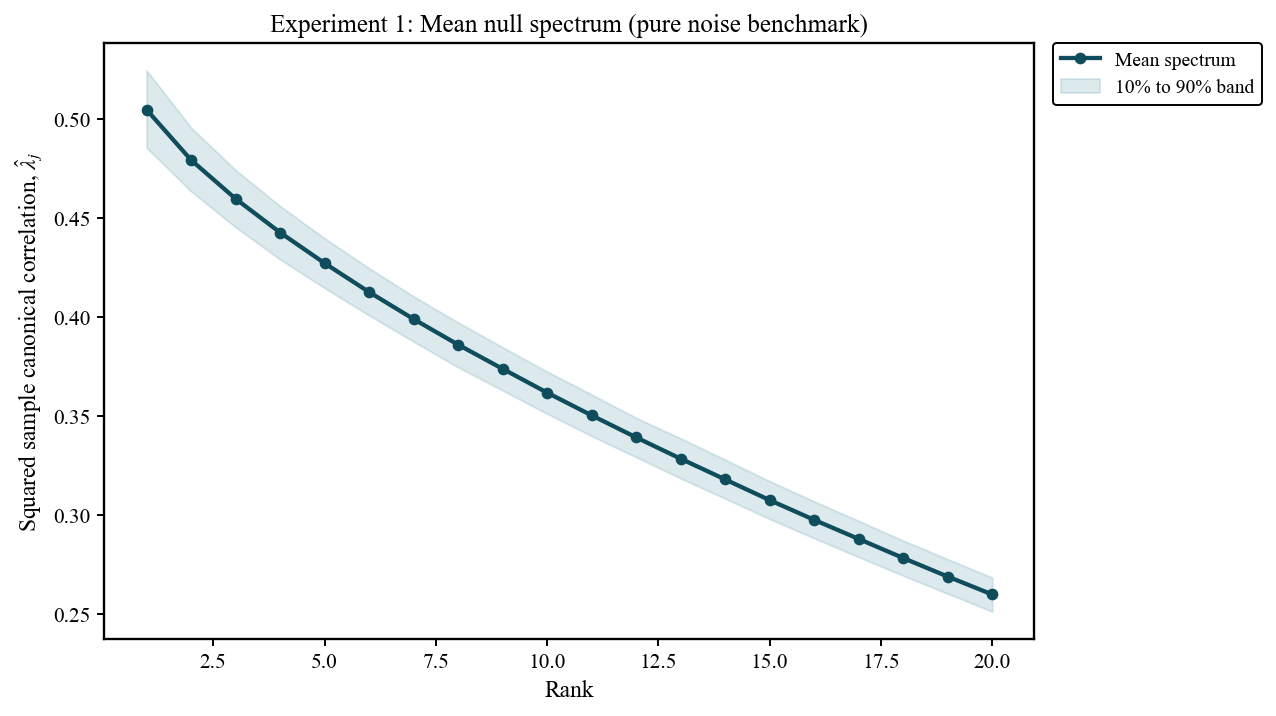

In [166]:
fig, ax = make_mean_scree_figure(
    null_res["spectra"],
    title="Experiment 1: Mean null spectrum (pure noise benchmark)",
    n_show=20,
)
plt.show()
# export scree plot
export_figure(fig, "mc_exp1_scree")
plt.close(fig)

Null distribution of the leading sample canonical correlation:

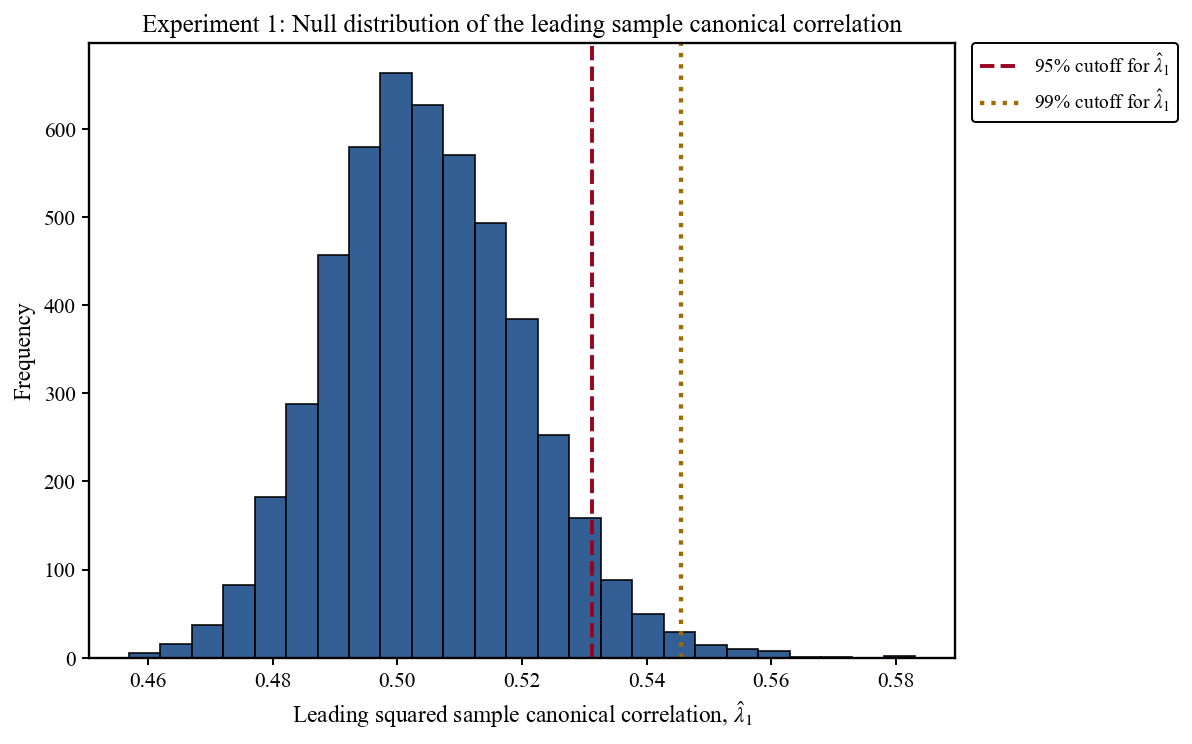

In [167]:
fig, ax = thesis_figure(figsize=(8.4, 5.2))
ax.hist(null_res["df"]["lambda1_hat"], bins=25, color=THESIS_COLORS["blue"], edgecolor="black", linewidth=0.9, alpha=0.9)
ax.axvline(null_res["null_cutoff_95"], linestyle="--", linewidth=2.0, color=THESIS_COLORS["red"], label=r"95% cutoff for $\hat{\lambda}_1$")
ax.axvline(null_res["null_cutoff_99"], linestyle=":", linewidth=2.2, color=THESIS_COLORS["gold"], label=r"99% cutoff for $\hat{\lambda}_1$")
ax.set_xlabel(r"Leading squared sample canonical correlation, $\hat{\lambda}_1$")
ax.set_ylabel("Frequency")
ax.set_title("Experiment 1: Null distribution of the leading sample canonical correlation")
style_axes(ax)
outside_legend(ax)
plt.show()
# export histogram 
export_figure(fig, "mc_exp1_histogram")
plt.close(fig)

**Wachter Bulk Overlay**: we pool all null canonical roots and overlays the Wachter density and the theoretical bulk edge.


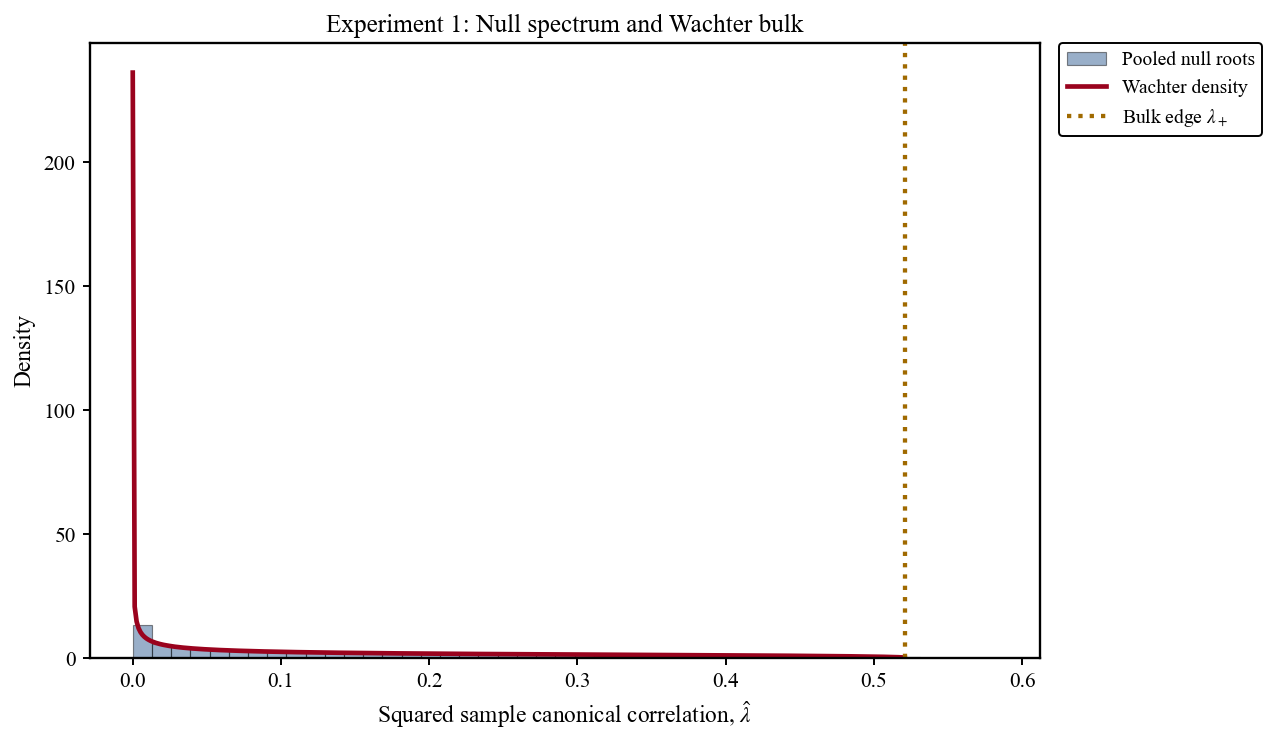

In [ ]:
fig, ax = thesis_figure(figsize=(9, 5.2))
pooled_null_roots = null_res["spectra"].ravel()
ax.hist(
    pooled_null_roots,
    bins=45,
    density=True,
    color=THESIS_COLORS["blue"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.45,
    label="Pooled null roots",
)
lam_minus, lam_plus = hdcca_lambda_edges(P0, Q0, N0)
x_grid = np.linspace(max(lam_minus + 1e-5, 1e-5), min(lam_plus - 1e-5, 1 - 1e-5), 400)
ax.plot(x_grid, wachter_density(x_grid, P0, Q0, N0), color=THESIS_COLORS["red"], linewidth=2.4, label="Wachter density")
ax.axvline(lam_plus, linestyle=":", linewidth=2.2, color=THESIS_COLORS["gold"], label=r"Bulk edge $\lambda_+$")
ax.set_xlabel(r"Squared sample canonical correlation, $\hat{\lambda}$")
ax.set_ylabel("Density")
ax.set_title("Experiment 1: Null spectrum and Wachter bulk")
style_axes(ax)
outside_legend(ax)
plt.show()
# this one is not exported as it is not very readable 

### 3.1.3. **Results**

Experiment 1 provides the null benchmark for the entire Monte Carlo study. When the two panels are truly independent, the leading sample canonical root is nevertheless large in finite samples: the mean of $\hat\lambda_1$ is 0.5047, with a standard deviation of 0.0156. The 95\% and 99\% null cutoffs are 0.5312 and 0.5454, respectively. This shows that, in a high-dimensional setting, naive CCA can generate apparently strong in-sample dependence even when the true cross-panel correlation is exactly zero.

The null design also reveals that this apparent signal is entirely unstable. The mean out-of-sample leading root is only 0.0039, while the split-sample squared cosine overlaps are approximately 0.0124 for the $X$-side vectors and 0.0124 for the $Y$-side vectors. In other words, the canonical directions extracted under the null do not replicate across samples. Taken together, these results imply that a large leading sample root is not, by itself, evidence of meaningful dependence. This experiment therefore provides the finite-sample reference distribution used later to distinguish genuine outliers from noise-generated spikes.


## **EXP2** — One-spike design

### 3.2.1. **Set-up**
This experiment answers:

- how the leading sample canonical correlation responds to stronger population dependence,
- how the second sample root behaves when there is only one true spike,
- how vector recovery improves as the signal gets stronger,
- and how much of the in-sample signal survives out of sample.

**DGP**: we include one nonzero population canonical correlation: `rhos = (rho,)`, where `rho` is varied over a grid (we maintain: Gaussian observations + identity within-panel covariance9.

This is the cleanest way to see the transition from **bulk absorption** at weak signal strength, to **clear outlier emergence** at strong signal strength.

In [168]:
def experiment_2_one_spike(
    p=P0, q=Q0, n=N0,
    rho_grid=None,
    mc_reps=REPS_MAIN_DESIGN,
    base_seed=2000
):
    if rho_grid is None:
        rho_grid = np.linspace(0.0, 0.95, 12)

    rows = []
    for i, rho in enumerate(rho_grid):
        for rep in range(mc_reps):
            seed = base_seed + i * 10000 + rep
            res = run_single_draw(
                p=p, q=q, n=n,
                rhos=(rho,),
                distribution="gaussian",
                random_state=seed
            )
            m = res["metrics_df"].iloc[0].to_dict()
            rows.append({
                "rho": rho,
                "lambda1_hat": res["lambda1_hat"],
                "lambda2_hat": res["lambda2_hat"],
                "lambda1_oos": res["lambda1_oos"],
                "split_sqcos_x": res["split_sqcos_x"],
                "split_sqcos_y": res["split_sqcos_y"],
                **m
            })

    df = pd.DataFrame(rows)
    return summarize_by_group(df, "rho"), df

In [169]:
exp2_summary, exp2_raw = experiment_2_one_spike()
exp2_summary.head()

,rho,lambda1_hat_mean,lambda1_hat_std,lambda2_hat_mean,lambda2_hat_std,lambda1_oos_mean,lambda1_oos_std,split_sqcos_x_mean,split_sqcos_x_std,split_sqcos_y_mean,split_sqcos_y_std,component_mean,component_std,rho2_mean,rho2_std,lambda_hat_mean,lambda_hat_std,bias_vs_rho2_mean,bias_vs_rho2_std,lambda_plus_mean,lambda_plus_std,rho2_critical_mean,rho2_critical_std,bg_attempted_mean,bg_attempted_std,bg_above_bulk_mean,bg_above_bulk_std,bg_has_real_roots_mean,bg_has_real_roots_std,bg_has_admissible_root_mean,bg_has_admissible_root_std,bg_applicable_mean,bg_applicable_std,bg_lower_root_mean,bg_lower_root_std,bg_upper_root_mean,bg_upper_root_std,bg_discriminant_mean,bg_discriminant_std,bg_rho2_hat_mean,bg_rho2_hat_std,bg_bias_vs_rho2_mean,bg_bias_vs_rho2_std,bg_pred_sin2_x_mean,bg_pred_sin2_x_std,bg_pred_sin2_y_mean,bg_pred_sin2_y_std,bg_pred_angle_x_deg_mean,bg_pred_angle_x_deg_std,bg_pred_angle_y_deg_mean,bg_pred_angle_y_deg_std,bg_angle_error_x_deg_mean,bg_angle_error_x_deg_std,bg_angle_error_y_deg_mean,bg_angle_error_y_deg_std,angle_x_deg_mean,angle_x_deg_std,angle_y_deg_mean,angle_y_deg_std,sqcos_x_mean,sqcos_x_std,sqcos_y_mean,sqcos_y_std
0,0.000000,0.504679,0.015488,0.479325,0.012482,0.003979,0.005204,0.012465,0.016972,0.012671,0.017456,1.0,0.0,0.000000,0.0,0.504679,0.015488,0.504679,0.015488,0.52071,0.0,0.181818,0.0,1.0,0.0,0.1560,0.362946,0.1560,0.362946,0.1560,0.362946,0.1560,0.362946,0.144909,0.015982,0.231054,0.026907,-14.013775,13.647546,0.231054,0.026907,0.231054,0.026907,0.721591,0.115934,0.721591,0.115934,58.717791,7.830292,58.717791,7.830292,-26.229705,8.954320,-26.651783,8.716720,84.925931,3.904633,85.023383,3.886880,0.012328,0.017386,0.011990,0.017394
1,0.086364,0.505143,0.015251,0.479039,0.012451,0.003908,0.005625,0.012332,0.017506,0.012561,0.017307,1.0,0.0,0.007459,0.0,0.505143,0.015251,0.497684,0.015251,0.52071,0.0,0.181818,0.0,1.0,0.0,0.1490,0.356178,0.1490,0.356178,0.1490,0.356178,0.1490,0.356178,0.144056,0.016508,0.232603,0.027626,-13.621940,13.473896,0.232603,0.027626,0.225145,0.027626,0.715538,0.119825,0.715538,0.119825,58.379235,8.156174,58.379235,8.156174,-26.112130,9.451460,-25.986595,9.222547,84.644074,4.032263,84.501879,4.026860,0.013507,0.018585,0.013961,0.018445
2,0.172727,0.505494,0.015387,0.480127,0.012853,0.003816,0.005088,0.012440,0.017274,0.012479,0.018783,1.0,0.0,0.029835,0.0,0.505494,0.015387,0.475659,0.015387,0.52071,0.0,0.181818,0.0,1.0,0.0,0.1600,0.366698,0.1600,0.366698,0.1600,0.366698,0.1600,0.366698,0.143832,0.015864,0.232773,0.026931,-13.307987,13.610441,0.232773,0.026931,0.202938,0.026931,0.713726,0.114794,0.713726,0.114794,58.155655,7.605350,58.155655,7.605350,-25.257347,8.927621,-25.096417,9.688282,83.608509,4.680702,83.808531,4.797239,0.018776,0.024859,0.018324,0.026283
3,0.259091,0.507315,0.015565,0.481682,0.012534,0.003825,0.005465,0.012963,0.018504,0.012470,0.017268,1.0,0.0,0.067128,0.0,0.507315,0.015565,0.440187,0.015565,0.52071,0.0,0.181818,0.0,1.0,0.0,0.1895,0.392003,0.1895,0.392003,0.1895,0.392003,0.1895,0.392003,0.143047,0.015537,0.233976,0.026810,-11.698296,13.844209,0.233976,0.026810,0.166847,0.026810,0.707945,0.112151,0.707945,0.112151,57.737038,7.347648,57.737038,7.347648,-23.665887,9.024146,-24.166397,9.177056,81.728423,6.083494,81.888113,6.052123,0.031165,0.040800,0.030308,0.039632
4,0.345455,0.509636,0.016013,0.483448,0.012668,0.003967,0.005470,0.012617,0.016906,0.012443,0.017011,1.0,0.0,0.119339,0.0,0.509636,0.016013,0.390297,0.016013,0.52071,0.0,0.181818,0.0,1.0,0.0,0.2280,0.419648,0.2280,0.419648,0.2280,0.419648,0.2280,0.419648,0.140633,0.016515,0.238366,0.028469,-9.617106,14.384205,0.238366,0.028469,0.119027,0.028469,0.690774,0.119334,0.690774,0.119334,56.741423,7.977795,56.741423,7.977795,-19.686340,11.501693,-19.887517,11.557885,77.925288,8.167121,77.897687,8.154572,0.061507,0.069334,0.061625,0.069519


In [170]:
# we export the summary as a table (rename cols for latex and readability)
exp2_table = exp2_summary[[
    "rho",
    "rho2_mean",
    "lambda1_hat_mean",
    "lambda2_hat_mean",
    "lambda1_oos_mean",
    "split_sqcos_x_mean",
    "split_sqcos_y_mean",
    "angle_x_deg_mean",
    "angle_y_deg_mean",
]].rename(columns={
    "rho": r"$\rho$",
    "rho2_mean": r"$\rho^2$",
    "lambda1_hat_mean": r"Mean $\hat{\lambda}_1$",
    "lambda2_hat_mean": r"Mean $\hat{\lambda}_2$",
    "lambda1_oos_mean": r"Mean out-of-sample $\hat{\lambda}_1$",
    "split_sqcos_x_mean": r"Mean split stability, $X$",
    "split_sqcos_y_mean": r"Mean split stability, $Y$",
    "angle_x_deg_mean": r"Mean angle, $X$ (deg)",
    "angle_y_deg_mean": r"Mean angle, $Y$ (deg)",
})
export_table(exp2_table, "mc_exp2_summary")

### 3.2.2. **Figures**

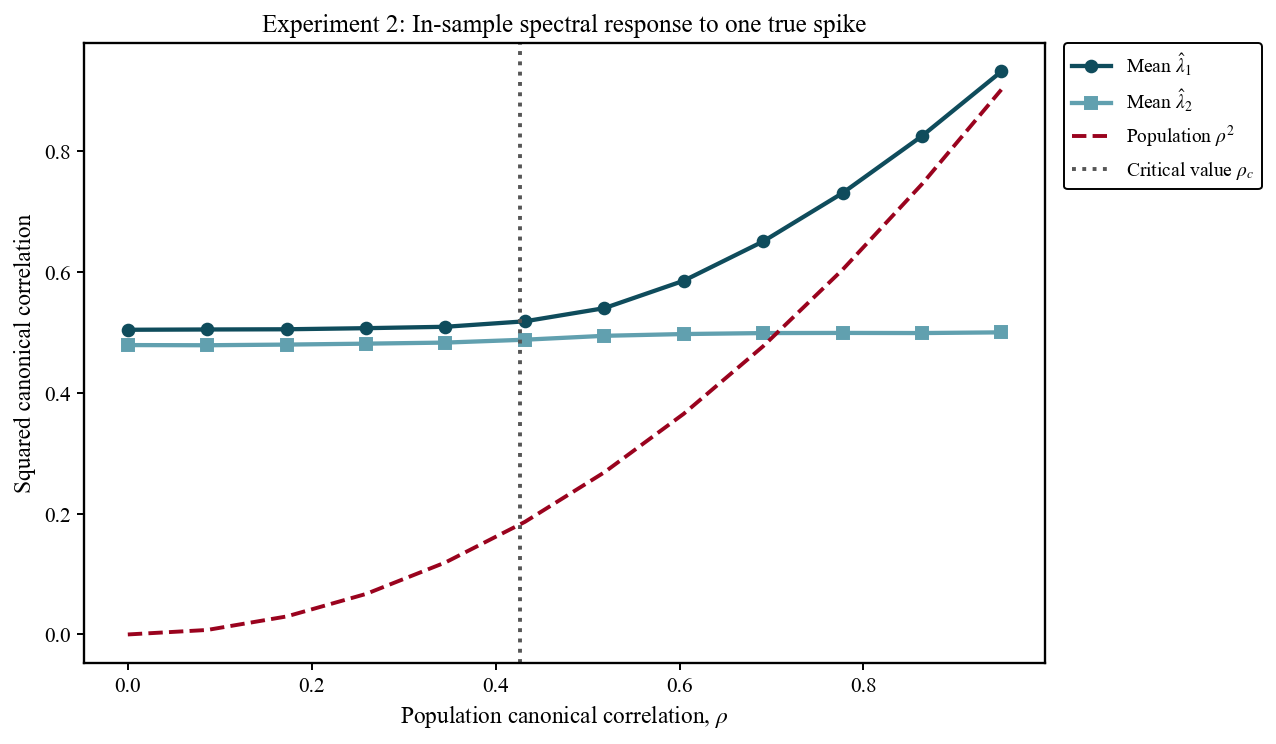

In [171]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp2_summary["rho"], exp2_summary["lambda1_hat_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["darkteal"], label=r"Mean $\hat{\lambda}_1$")
ax.plot(exp2_summary["rho"], exp2_summary["lambda2_hat_mean"], marker="s", linewidth=2.2, 
        color=THESIS_COLORS["teal"], label=r"Mean $\hat{\lambda}_2$")
ax.plot(exp2_summary["rho"], exp2_summary["rho2_mean"], linestyle="--", linewidth=2.0, 
        color=THESIS_COLORS["red"], label=r"Population $\rho^2$")
ax.axvline(rho_c, linestyle=":", linewidth=2.0, 
           color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Squared canonical correlation")
ax.set_title("Experiment 2: In-sample spectral response to one true spike")
style_axes(ax)
outside_legend(ax)
plt.show()
#export the spectral fig
export_figure(fig, "mc_exp2_spectral")
plt.close(fig)

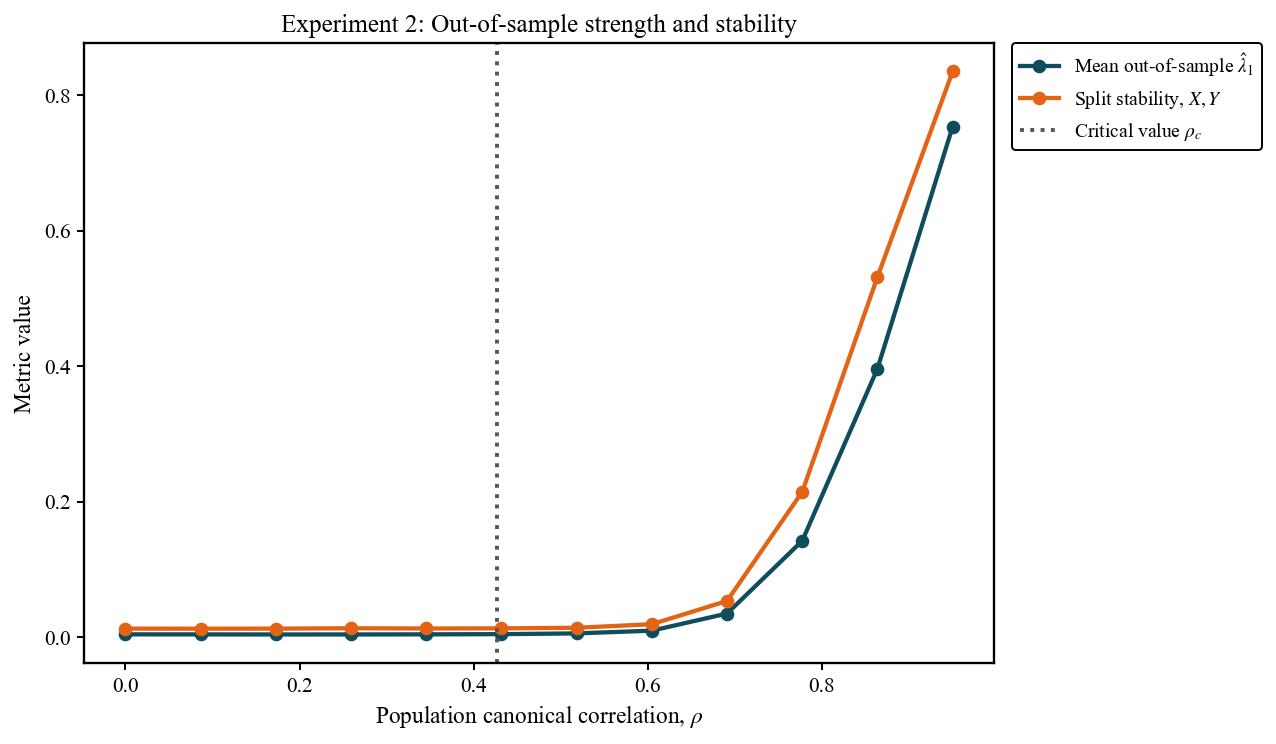

In [172]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp2_summary["rho"], exp2_summary["lambda1_oos_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["darkteal"], label=r"Mean out-of-sample $\hat{\lambda}_1$")
ax.plot(exp2_summary["rho"], exp2_summary["split_sqcos_x_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["autumn"], label=r"Split stability, $X, Y$")
ax.axvline(rho_c, linestyle=":", linewidth=2.0, color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Metric value")
ax.set_title("Experiment 2: Out-of-sample strength and stability")
style_axes(ax)
outside_legend(ax)
plt.show()

# export the stability fig
export_figure(fig, "mc_exp2_stability")
plt.close(fig)


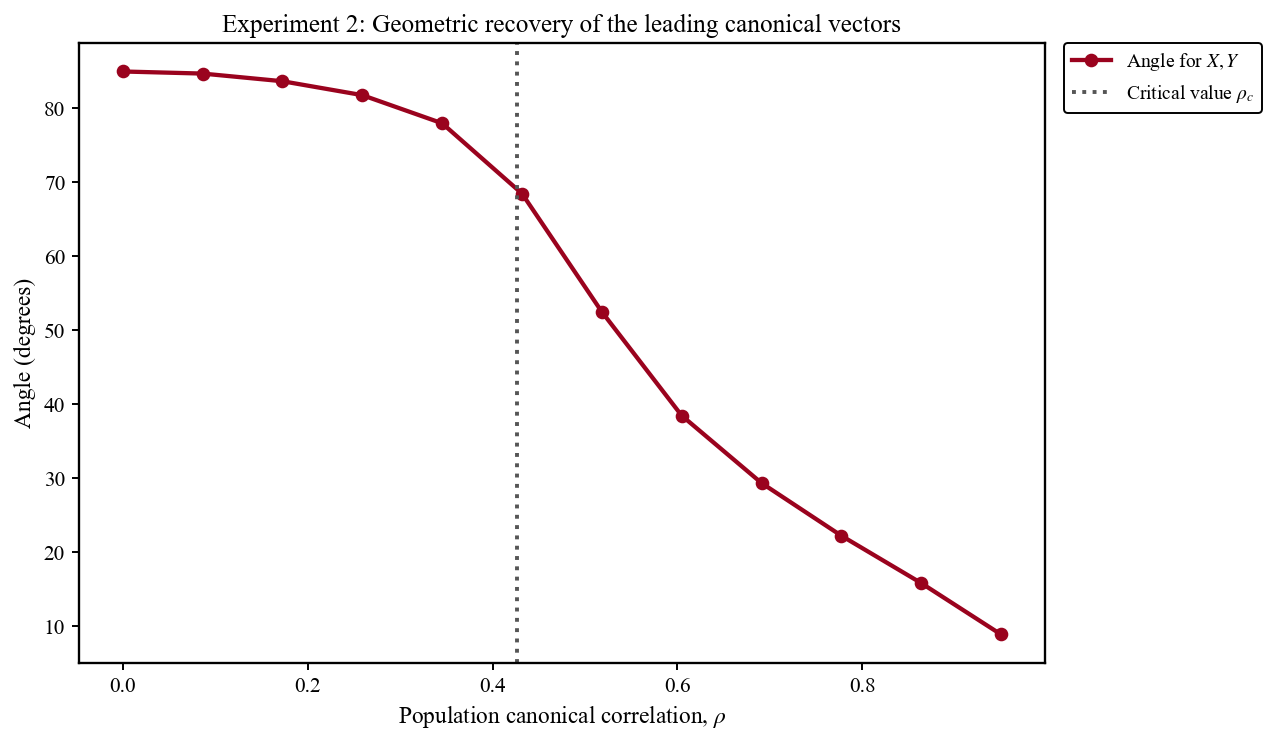

In [173]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp2_summary["rho"], exp2_summary["angle_x_deg_mean"], marker="o", linewidth=2.2, color=THESIS_COLORS["red"], label=r"Angle for $X, Y$")
ax.axvline(rho_c, linestyle=":", linewidth=2.0, color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Angle (degrees)")
ax.set_title("Experiment 2: Geometric recovery of the leading canonical vectors")
style_axes(ax)
outside_legend(ax)
plt.show()
# export teh angle fig
export_figure(fig, "mc_exp2_angles")
plt.close(fig)

*Note that because p=q=80 we get the same angle so we could change the graph and only report one*

### 3.2.3. **BG corrections**

In [174]:
bg_exp2_summary = summarize_bg_validation(exp2_raw)
bg_exp2_summary

,rho,rho2,lambda1_mean,raw_bias_mean,bg_attempted_share,bg_above_bulk_share,bg_valid_share,bg_applicable_share,bg_rho2_mean,bg_bias_mean,observed_angle_x_mean,bg_pred_angle_x_mean,bg_angle_error_x_mean,observed_angle_y_mean,bg_pred_angle_y_mean,bg_angle_error_y_mean,bias_reduction_vs_raw
0,0.000000,0.000000,0.504679,0.504679,1.0,0.1560,0.1560,0.1560,0.231054,0.231054,84.925931,58.717791,-26.229705,85.023383,58.717791,-26.651783,0.542177
1,0.086364,0.007459,0.505143,0.497684,1.0,0.1490,0.1490,0.1490,0.232603,0.225145,84.644074,58.379235,-26.112130,84.501879,58.379235,-25.986595,0.547615
2,0.172727,0.029835,0.505494,0.475659,1.0,0.1600,0.1600,0.1600,0.232773,0.202938,83.608509,58.155655,-25.257347,83.808531,58.155655,-25.096417,0.573354
3,0.259091,0.067128,0.507315,0.440187,1.0,0.1895,0.1895,0.1895,0.233976,0.166847,81.728423,57.737038,-23.665887,81.888113,57.737038,-24.166397,0.620962
4,0.345455,0.119339,0.509636,0.390297,1.0,0.2280,0.2280,0.2280,0.238366,0.119027,77.925288,56.741423,-19.686340,77.897687,56.741423,-19.887517,0.695035
5,0.431818,0.186467,0.518678,0.332211,1.0,0.4380,0.4380,0.4380,0.246573,0.060106,68.427735,54.848490,-10.666868,68.438806,54.848490,-10.743241,0.819071
6,0.518182,0.268512,0.540473,0.271961,1.0,0.8060,0.8060,0.8060,0.280126,0.011613,52.451142,48.317783,-2.460406,52.506232,48.317783,-2.573309,0.957298
7,0.604545,0.365475,0.585884,0.220409,1.0,0.9970,0.9970,0.9970,0.361909,-0.003566,38.433370,37.075600,-1.328715,38.503030,37.075600,-1.398100,0.983819
8,0.690909,0.477355,0.650980,0.173625,1.0,1.0000,1.0000,1.0000,0.475543,-0.001813,29.318107,27.822231,-1.495876,29.335887,27.822231,-1.513656,0.989559
9,0.777273,0.604153,0.731077,0.126925,1.0,1.0000,1.0000,1.0000,0.602425,-0.001728,22.196973,20.914564,-1.282409,22.250565,20.914564,-1.336000,0.986388


In [175]:
# rename cols and export 
bg_exp2_table = bg_exp2_summary[[
    "rho",
    "rho2",
    "lambda1_mean",
    "raw_bias_mean",
    "bg_attempted_share",
    "bg_above_bulk_share",
    "bg_valid_share",
    "bg_rho2_mean",
    "bg_bias_mean",
    "bias_reduction_vs_raw",
    "observed_angle_x_mean",
    "bg_pred_angle_x_mean",
    "bg_angle_error_x_mean",
]].rename(columns={
    "rho": r"$\rho$",
    "rho2": r"$\rho^2$",
    "lambda1_mean": r"Mean raw $\hat{\lambda}_1$",
    "raw_bias_mean": "Mean raw bias",
    "bg_attempted_share": "BG attempted share",
    "bg_above_bulk_share": "Above-bulk share",
    "bg_valid_share": "Valid BG share",
    "bg_rho2_mean": r"Mean BG $\widehat{\rho^2}$",
    "bg_bias_mean": "Mean BG bias",
    "bias_reduction_vs_raw": "Bias reduction",
    "observed_angle_x_mean": r"Observed angle, $X$ (deg)",
    "bg_pred_angle_x_mean": r"BG angle, $X$ (deg)",
    "bg_angle_error_x_mean": r"BG angle error, $X$ (deg)",
})
export_table(bg_exp2_table, "mc_exp2_bg_correction_summary")

In [176]:
bg_exp2_status = summarize_bg_status(exp2_raw)
bg_exp2_status

,rho,bg_status,n,share
0,0.000000,inside_or_below_bulk,1688,0.8440
1,0.000000,valid_outlier,312,0.1560
2,0.086364,inside_or_below_bulk,1702,0.8510
3,0.086364,valid_outlier,298,0.1490
4,0.172727,inside_or_below_bulk,1680,0.8400
5,0.172727,valid_outlier,320,0.1600
6,0.259091,inside_or_below_bulk,1621,0.8105
7,0.259091,valid_outlier,379,0.1895
8,0.345455,inside_or_below_bulk,1544,0.7720
9,0.345455,valid_outlier,456,0.2280


In [177]:
# rename cols and export 
bg_exp2_status_table = bg_exp2_status.rename(columns={
    "rho": r"$\rho$",
    "bg_status": "BG correction status",
    "n": "Draws",
    "share": "Share",
})
export_table(bg_exp2_status_table, "mc_exp2_bg_status_summary")

### 3.2.4. **Results**

Experiment 2 studies how the leading canonical root reacts when a single true population spike is introduced and its strength is varied. The theoretical high-dimensional threshold is approximately $\rho_c \approx 0.426$, so the key question is whether the sample spectrum begins to separate from the null benchmark before that point. The results indicate that, throughout the weak-signal region, the leading sample root remains very close to its null value. As $\rho$ increases from 0 to 0.345, the mean of $\hat\lambda_1$ rises only from 0.5047 to 0.5098, while the second sample root remains essentially unchanged, moving only from 0.4793 to 0.4840. Hence, for subcritical or near-subcritical signal strengths, the sample spectrum is still largely dominated by the high-dimensional noise bulk.

The instability diagnostics reinforce this conclusion. Over the same range, the mean out-of-sample leading root stays near zero, fluctuating around 0.004, which is negligible relative to the in-sample value of about 0.50. Likewise, the estimated canonical vectors remain poorly recovered: the average angles are still extremely large, falling only from about $85^\circ$ to $78^\circ$, and the squared cosine overlaps rise only modestly from roughly 0.01 to 0.06. These findings imply that weak population dependence is absorbed into the bulk rather than emerging as a clean, interpretable outlier. Thus, before the signal reaches the threshold region, naive CCA substantially overstates the strength of dependence in-sample while delivering almost no out-of-sample persistence or reliable vector recovery.

## **EXP3** — Near-threshold zoom

### 3.3.1. **Set-up**

Experiment 3 focuses on the **region around the HDCCA threshold**. The reason for isolating this region is that the theoretical prediction is not just that strong signals are easier to estimate, it's that there is a **detectability boundary**.

Below the threshold:
- the spike is absorbed by the bulk,
- the leading sample root is hard to distinguish from null noise,
- and the estimated vectors remain very unstable.

Above the threshold the spike separates --> detection probability rises --> and vector recovery improves.

*We declare a spike to be detected when the top sample root exceeds the **99% null cutoff** from Experiment 1.*

In [178]:
def experiment_3_threshold_zoom(
    p=P0, q=Q0, n=N0,
    offsets=(-0.12, -0.08, -0.04, 0.0, 0.04, 0.08, 0.12),
    mc_reps=REPS_NEAR_CRITICAL,
    base_seed=3000,
    detection_cutoff=None
):
    rho_c = hdcca_threshold_rho(p, q, n)
    rho_grid = np.clip(rho_c + np.array(offsets), 0.0, 0.99)

    rows = []
    for i, rho in enumerate(rho_grid):
        for rep in range(mc_reps):
            seed = base_seed + i * 10000 + rep
            res = run_single_draw(
                p=p, q=q, n=n,
                rhos=(rho,),
                distribution="gaussian",
                random_state=seed
            )
            m = res["metrics_df"].iloc[0].to_dict()
            rows.append({
                "rho": rho,
                "detected": float(res["lambda1_hat"] > detection_cutoff),
                "lambda1_hat": res["lambda1_hat"],
                "lambda1_oos": res["lambda1_oos"],
                "split_sqcos_x": res["split_sqcos_x"],
                "split_sqcos_y": res["split_sqcos_y"],
                **m
            })

    df = pd.DataFrame(rows)
    return rho_c, summarize_by_group(df, "rho"), df

In [179]:
rho_c_zoom, exp3_summary, exp3_raw = experiment_3_threshold_zoom(
    detection_cutoff=null_res["null_cutoff_99"]
)
exp3_summary

,rho,detected_mean,detected_std,lambda1_hat_mean,lambda1_hat_std,lambda1_oos_mean,lambda1_oos_std,split_sqcos_x_mean,split_sqcos_x_std,split_sqcos_y_mean,split_sqcos_y_std,component_mean,component_std,rho2_mean,rho2_std,lambda_hat_mean,lambda_hat_std,bias_vs_rho2_mean,bias_vs_rho2_std,lambda_plus_mean,lambda_plus_std,rho2_critical_mean,rho2_critical_std,bg_attempted_mean,bg_attempted_std,bg_above_bulk_mean,bg_above_bulk_std,bg_has_real_roots_mean,bg_has_real_roots_std,bg_has_admissible_root_mean,bg_has_admissible_root_std,bg_applicable_mean,bg_applicable_std,bg_lower_root_mean,bg_lower_root_std,bg_upper_root_mean,bg_upper_root_std,bg_discriminant_mean,bg_discriminant_std,bg_rho2_hat_mean,bg_rho2_hat_std,bg_bias_vs_rho2_mean,bg_bias_vs_rho2_std,bg_pred_sin2_x_mean,bg_pred_sin2_x_std,bg_pred_sin2_y_mean,bg_pred_sin2_y_std,bg_pred_angle_x_deg_mean,bg_pred_angle_x_deg_std,bg_pred_angle_y_deg_mean,bg_pred_angle_y_deg_std,bg_angle_error_x_deg_mean,bg_angle_error_x_deg_std,bg_angle_error_y_deg_mean,bg_angle_error_y_deg_std,angle_x_deg_mean,angle_x_deg_std,angle_y_deg_mean,angle_y_deg_std,sqcos_x_mean,sqcos_x_std,sqcos_y_mean,sqcos_y_std
0,0.306401,0.0134,0.114992,0.508110,0.015402,0.003910,0.005525,0.011987,0.016693,0.012814,0.017076,1.0,0.0,0.093882,0.0,0.508110,0.015402,0.414228,0.015402,0.52071,0.0,0.181818,0.0,1.0,0.0,0.2014,0.401086,0.2014,0.401086,0.2014,0.401086,0.2014,0.401086,0.142936,0.016270,0.234375,0.027534,-11.005007,13.761508,0.234375,0.027534,0.140493,0.027534,0.707350,0.117921,0.707350,0.117921,57.818287,7.986433,57.818287,7.986433,-21.568915,10.989145,-21.277167,10.963895,80.016056,6.976080,80.045295,6.997017,0.043499,0.052238,0.043395,0.052714
1,0.346401,0.0196,0.138635,0.509967,0.016028,0.004001,0.005665,0.012513,0.017156,0.012560,0.017338,1.0,0.0,0.119994,0.0,0.509967,0.016028,0.389973,0.016028,0.52071,0.0,0.181818,0.0,1.0,0.0,0.2398,0.427004,0.2398,0.427004,0.2398,0.427004,0.2398,0.427004,0.141582,0.016566,0.236809,0.028698,-9.321228,14.413044,0.236809,0.028698,0.116815,0.028698,0.697635,0.119613,0.697635,0.119613,57.165290,7.940891,57.165290,7.940891,-18.620497,11.403628,-18.943143,11.439425,77.409880,8.374773,77.358049,8.395869,0.066052,0.072296,0.066501,0.072795
2,0.386401,0.0282,0.165560,0.512848,0.016353,0.003983,0.005480,0.013063,0.018235,0.012885,0.018090,1.0,0.0,0.149306,0.0,0.512848,0.016353,0.363542,0.016353,0.52071,0.0,0.181818,0.0,1.0,0.0,0.3086,0.461962,0.3086,0.461962,0.3086,0.461962,0.3086,0.461962,0.141131,0.017412,0.237935,0.030364,-6.719940,14.875022,0.237935,0.030364,0.088629,0.030364,0.694623,0.125687,0.694623,0.125687,57.045414,8.416792,57.045414,8.416792,-14.319205,12.607519,-14.339454,12.432918,73.781195,9.883491,73.887004,9.812625,0.102096,0.098024,0.100815,0.097076
3,0.426401,0.0606,0.238619,0.517204,0.017277,0.004235,0.006138,0.013054,0.017799,0.012349,0.016937,1.0,0.0,0.181818,0.0,0.517204,0.017277,0.335386,0.017277,0.52071,0.0,0.181818,0.0,1.0,0.0,0.3994,0.489824,0.3994,0.489824,0.3994,0.489824,0.3994,0.489824,0.137417,0.017877,0.244788,0.032906,-2.703810,16.044508,0.244788,0.032906,0.062969,0.032906,0.668067,0.128067,0.668067,0.128067,55.320276,8.343303,55.320276,8.343303,-10.432544,12.234964,-10.461097,12.114513,68.926942,11.180251,68.923560,11.090273,0.156976,0.125571,0.156663,0.123964
4,0.466401,0.1380,0.344934,0.524526,0.018632,0.004484,0.006509,0.012908,0.017967,0.012934,0.017675,1.0,0.0,0.217530,0.0,0.524526,0.018632,0.306995,0.018632,0.52071,0.0,0.181818,0.0,1.0,0.0,0.5452,0.498003,0.5452,0.498003,0.5452,0.498003,0.5452,0.498003,0.131755,0.018484,0.255949,0.036501,4.192116,17.850294,0.255949,0.036501,0.038419,0.036501,0.627997,0.131101,0.627997,0.131101,52.805683,8.291051,52.805683,8.291051,-6.489493,11.704195,-6.576784,11.744618,62.452063,11.634068,62.591853,11.667252,0.238866,0.147535,0.237078,0.147870
5,0.506401,0.3264,0.468942,0.536811,0.021765,0.004821,0.007024,0.013228,0.018299,0.013449,0.018339,1.0,0.0,0.256442,0.0,0.536811,0.021765,0.280368,0.021765,0.52071,0.0,0.18181

In [229]:
# we export the summary as a tabla that can be included in the thesis
exp3_table = exp3_summary[[
    "rho",
    "detected_mean",
    "lambda1_hat_mean",
    "lambda1_oos_mean",
    "split_sqcos_x_mean",
    "split_sqcos_y_mean",
    "angle_x_deg_mean",
    "angle_y_deg_mean",
]].rename(columns={
    "rho": r"$\rho$",
    "detected_mean": "Detection probability",
    "lambda1_hat_mean": r"Mean $\hat{\lambda}_1$",
    "lambda1_oos_mean": r"Mean out-of-sample $\hat{\lambda}_1$",
    "split_sqcos_x_mean": r"Mean split stability, $X$",
    "split_sqcos_y_mean": r"Mean split stability, $Y$",
    "angle_x_deg_mean": r"Mean angle, $X$ (deg)",
    "angle_y_deg_mean": r"Mean angle, $Y$ (deg)",
})
export_table(exp3_table, "mc_exp3_summary")

### 3.3.2. **Figures**

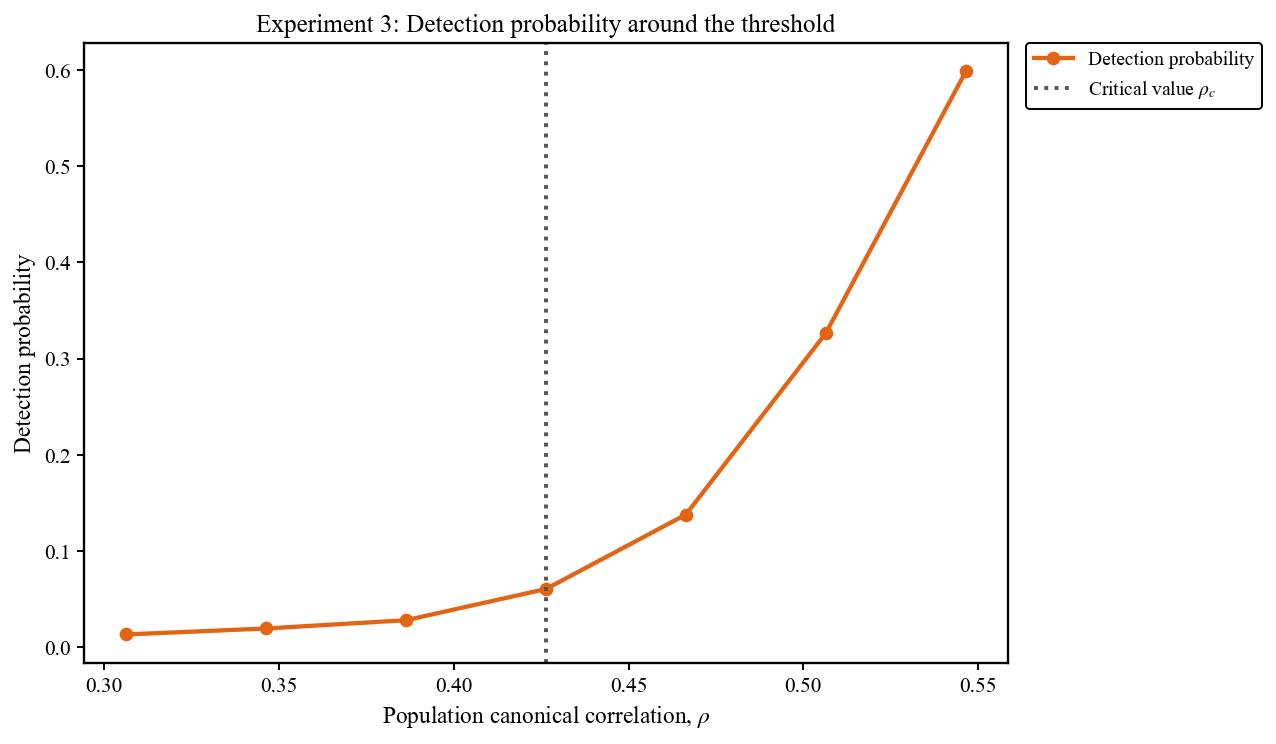

In [230]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp3_summary["rho"], exp3_summary["detected_mean"], marker="o", linewidth=2.2, color=THESIS_COLORS["autumn"], label="Detection probability")
ax.axvline(rho_c_zoom, linestyle=":", linewidth=2.0, color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Detection probability")
ax.set_title("Experiment 3: Detection probability around the threshold")
style_axes(ax)
outside_legend(ax)
plt.show()

#export figure 
export_figure(fig, "mc_exp3_detection")
plt.close(fig)

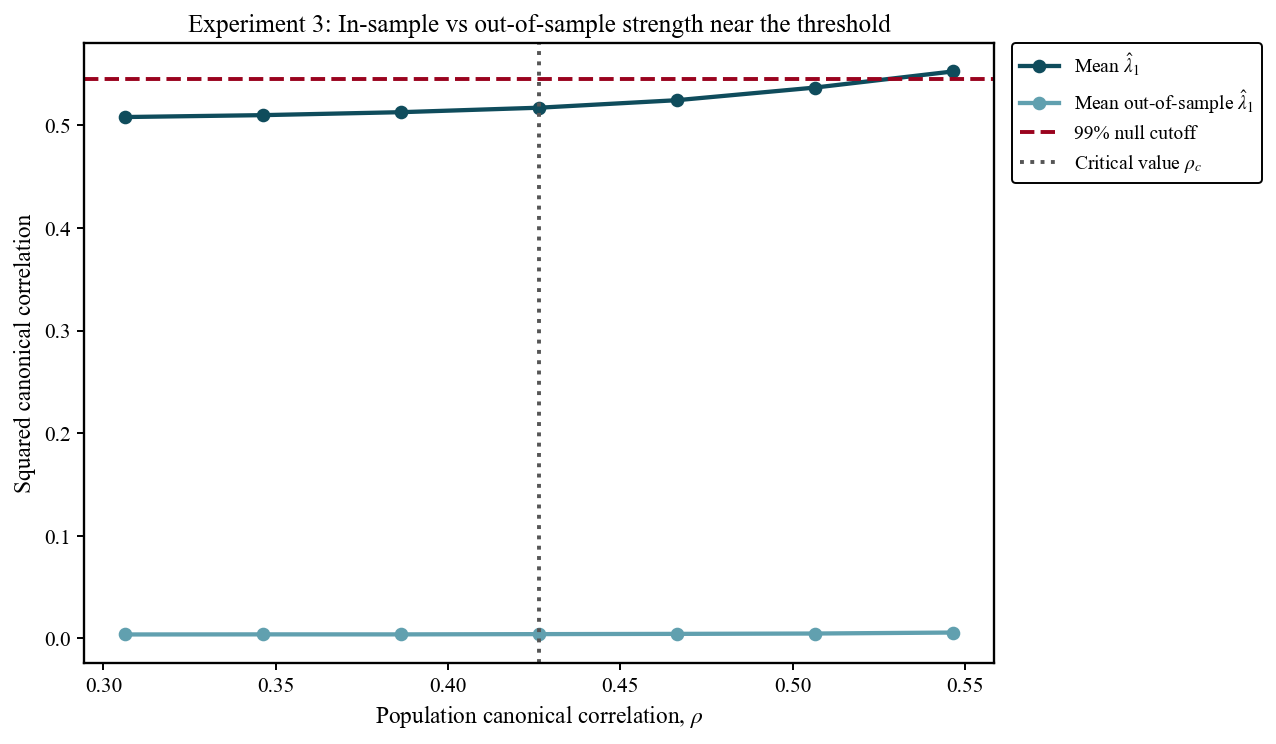

In [231]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp3_summary["rho"], exp3_summary["lambda1_hat_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["darkteal"], label=r"Mean $\hat{\lambda}_1$")
ax.plot(exp3_summary["rho"], exp3_summary["lambda1_oos_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["teal"], label=r"Mean out-of-sample $\hat{\lambda}_1$")
ax.axhline(null_res["null_cutoff_99"], linestyle="--", linewidth=2.0, color=THESIS_COLORS["red"], label=r"99% null cutoff")
ax.axvline(rho_c_zoom, linestyle=":", linewidth=2.0, color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Squared canonical correlation")
ax.set_title("Experiment 3: In-sample vs out-of-sample strength near the threshold")
style_axes(ax)
outside_legend(ax)
plt.show()

# export figure
export_figure(fig, "mc_exp3_strength")
plt.close(fig)

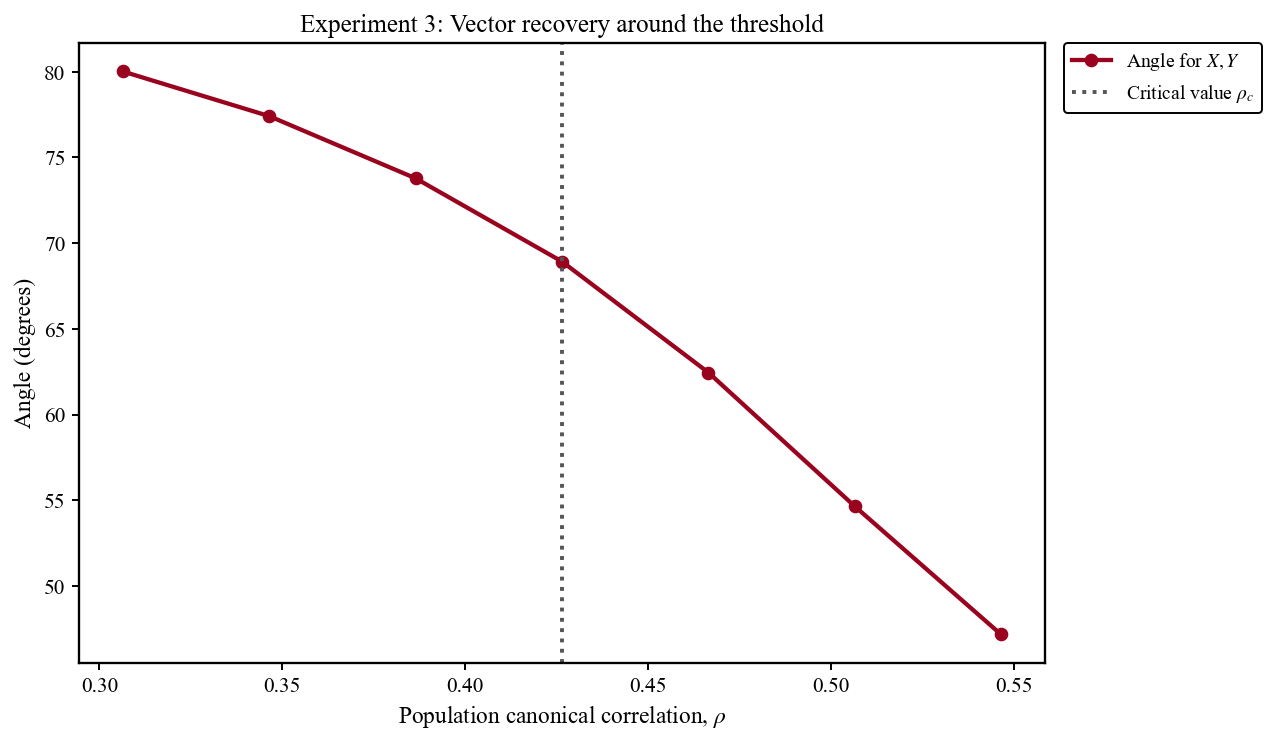

In [232]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp3_summary["rho"], exp3_summary["angle_x_deg_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["red"], label=r"Angle for $X, Y$")
ax.axvline(rho_c_zoom, linestyle=":", linewidth=2.0, color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Angle (degrees)")
ax.set_title("Experiment 3: Vector recovery around the threshold")
style_axes(ax)
outside_legend(ax)
plt.show()
# export figrue 
export_figure(fig, "mc_exp3_angles")
plt.close(fig)

### 3.3.3. **BG corrections**

We now test the correction formulas. Because the Monte Carlo design knows the true population spike, each simulated draw can be used to compare:

- the true population squared canonical correlation,
- the raw sample root,
- the BG-corrected estimate, obtained by inverting the outlier-location formula whenever the algebra identifies an admissible above-threshold root.

The same draw also compares the realized angle between the sample and population canonical variables with the theoretical angle implied by the BG formula. 

In [180]:
bg_exp3_summary = summarize_bg_validation(exp3_raw)
bg_exp3_summary

,rho,rho2,lambda1_mean,raw_bias_mean,bg_attempted_share,bg_above_bulk_share,bg_valid_share,bg_applicable_share,bg_rho2_mean,bg_bias_mean,observed_angle_x_mean,bg_pred_angle_x_mean,bg_angle_error_x_mean,observed_angle_y_mean,bg_pred_angle_y_mean,bg_angle_error_y_mean,bias_reduction_vs_raw
0,0.306401,0.093882,0.508110,0.414228,1.0,0.2014,0.2014,0.2014,0.234375,0.140493,80.016056,57.818287,-21.568915,80.045295,57.818287,-21.277167,0.660831
1,0.346401,0.119994,0.509967,0.389973,1.0,0.2398,0.2398,0.2398,0.236809,0.116815,77.409880,57.165290,-18.620497,77.358049,57.165290,-18.943143,0.700455
2,0.386401,0.149306,0.512848,0.363542,1.0,0.3086,0.3086,0.3086,0.237935,0.088629,73.781195,57.045414,-14.319205,73.887004,57.045414,-14.339454,0.756207
3,0.426401,0.181818,0.517204,0.335386,1.0,0.3994,0.3994,0.3994,0.244788,0.062969,68.926942,55.320276,-10.432544,68.923560,55.320276,-10.461097,0.812248
4,0.466401,0.217530,0.524526,0.306995,1.0,0.5452,0.5452,0.5452,0.255949,0.038419,62.452063,52.805683,-6.489493,62.591853,52.805683,-6.576784,0.874855
5,0.506401,0.256442,0.536811,0.280368,1.0,0.7578,0.7578,0.7578,0.274722,0.018280,54.649601,49.254074,-3.299148,54.691698,49.254074,-3.390062,0.934801
6,0.546401,0.298555,0.552499,0.253944,1.0,0.9156,0.9156,0.9156,0.300380,0.001825,47.167368,45.014074,-1.345121,47.147550,45.014074,-1.351227,0.992813


In [181]:
# rename cols and export 
bg_exp3_table = bg_exp3_summary[[
    "rho",
    "rho2",
    "lambda1_mean",
    "raw_bias_mean",
    "bg_attempted_share",
    "bg_above_bulk_share",
    "bg_valid_share",
    "bg_rho2_mean",
    "bg_bias_mean",
    "bias_reduction_vs_raw",
    "observed_angle_x_mean",
    "bg_pred_angle_x_mean",
    "bg_angle_error_x_mean",
]].rename(columns={
    "rho": r"$\rho$",
    "rho2": r"$\rho^2$",
    "lambda1_mean": r"Mean raw $\hat{\lambda}_1$",
    "raw_bias_mean": "Mean raw bias",
    "bg_attempted_share": "BG attempted share",
    "bg_above_bulk_share": "Above-bulk share",
    "bg_valid_share": "Valid BG share",
    "bg_rho2_mean": r"Mean BG $\widehat{\rho^2}$",
    "bg_bias_mean": "Mean BG bias",
    "bias_reduction_vs_raw": "Bias reduction",
    "observed_angle_x_mean": r"Observed angle, $X$ (deg)",
    "bg_pred_angle_x_mean": r"BG angle, $X$ (deg)",
    "bg_angle_error_x_mean": r"BG angle error, $X$ (deg)",
})
export_table(bg_exp3_table, "mc_exp3_bg_correction_summary")

In [182]:
bg_exp3_status = summarize_bg_status(exp3_raw)
bg_exp3_status

,rho,bg_status,n,share
0,0.306401,inside_or_below_bulk,3993,0.7986
1,0.306401,valid_outlier,1007,0.2014
2,0.346401,inside_or_below_bulk,3801,0.7602
3,0.346401,valid_outlier,1199,0.2398
4,0.386401,inside_or_below_bulk,3457,0.6914
5,0.386401,valid_outlier,1543,0.3086
6,0.426401,inside_or_below_bulk,3003,0.6006
7,0.426401,valid_outlier,1997,0.3994
8,0.466401,inside_or_below_bulk,2274,0.4548
9,0.466401,valid_outlier,2726,0.5452


In [183]:
# rename cols and export 
bg_exp3_status_table = bg_exp3_status.rename(columns={
    "rho": r"$\rho$",
    "bg_status": "BG correction status",
    "n": "Draws",
    "share": "Share",
})
export_table(bg_exp3_status_table, "mc_exp3_bg_status_summary")

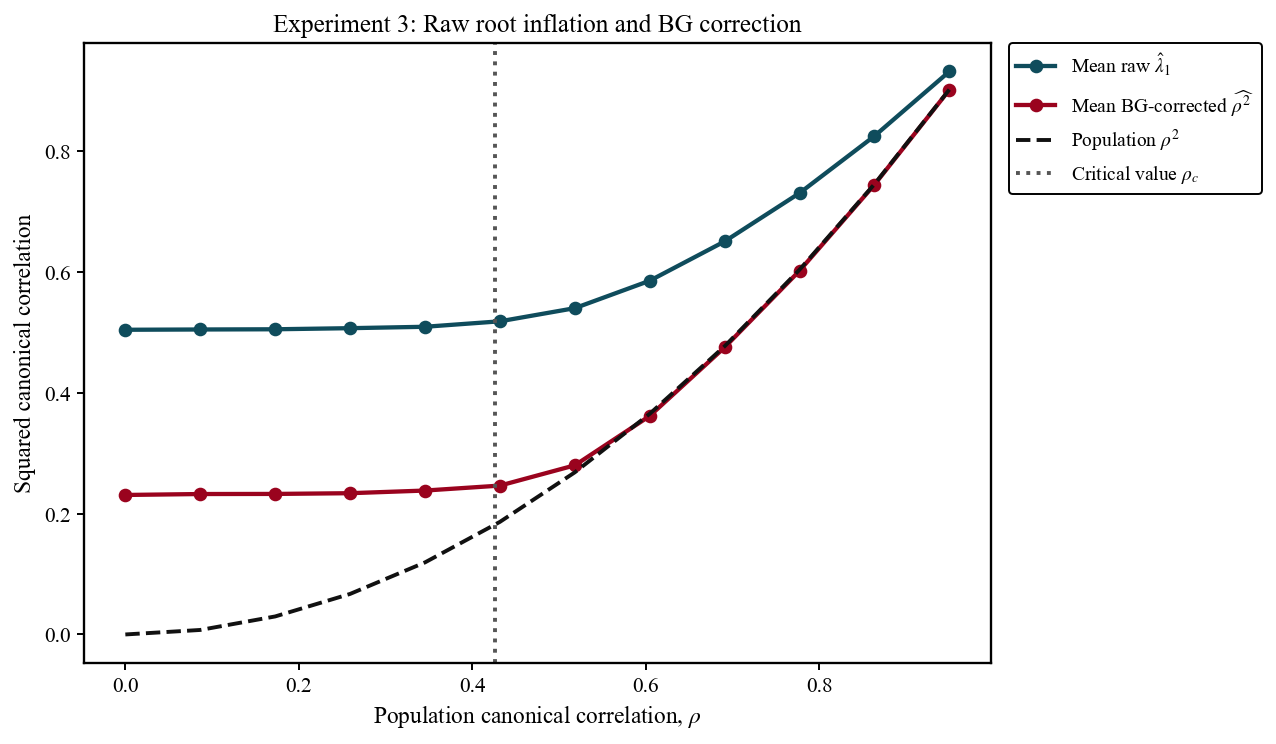

In [184]:
# same fig as before but add BG-corrected estimate
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["lambda1_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["darkteal"], label=r"Mean raw $\hat{\lambda}_1$")
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["bg_rho2_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["red"], label=r"Mean BG-corrected $\widehat{\rho^2}$")
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["rho2"], linestyle="--", linewidth=2.0, 
        color=THESIS_COLORS["charcoal"], label=r"Population $\rho^2$")
ax.axvline(rho_c, linestyle=":", linewidth=2.0, 
           color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Squared canonical correlation")
ax.set_title("Experiment 3: Raw root inflation and BG correction")
style_axes(ax)
outside_legend(ax)
plt.show()

#export figure
export_figure(fig, "mc_exp3_bg_root_correction")
plt.close(fig)

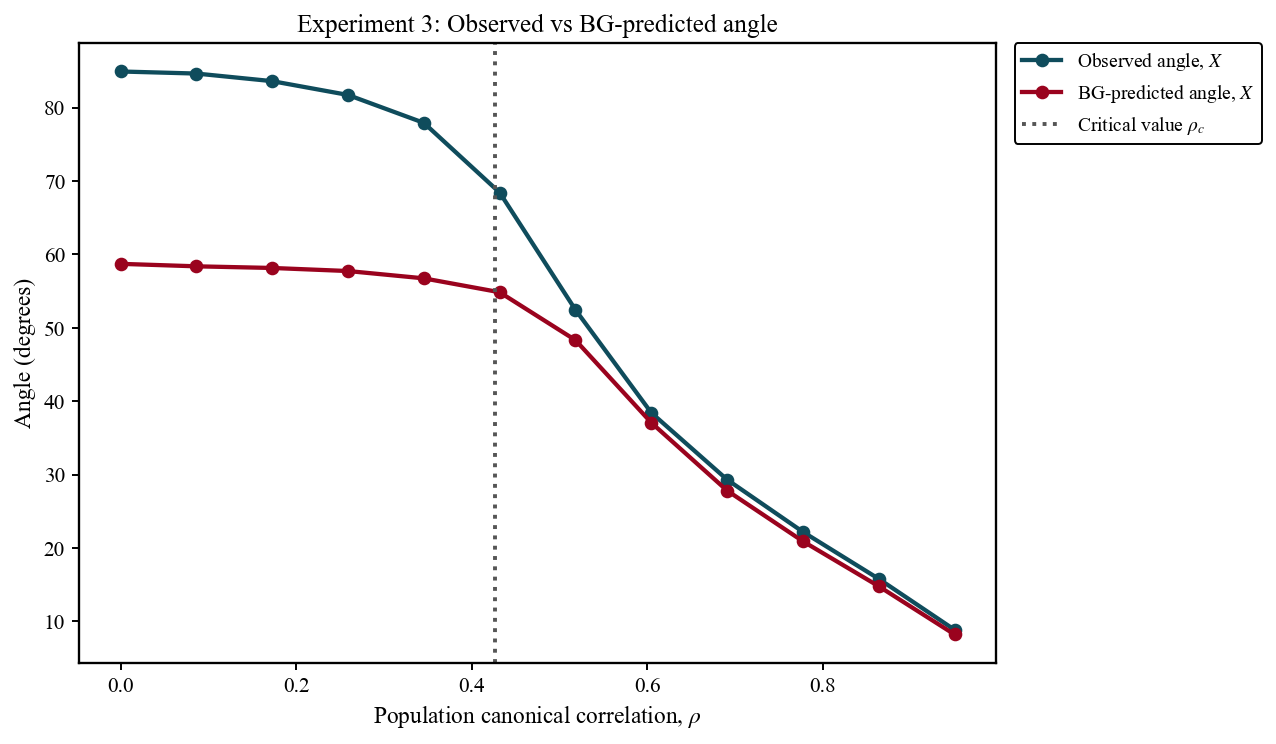

In [185]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["observed_angle_x_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["darkteal"], label=r"Observed angle, $X$")
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["bg_pred_angle_x_mean"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["red"], label=r"BG-predicted angle, $X$")
ax.axvline(rho_c, linestyle=":", linewidth=2.0, color=THESIS_COLORS["grey"], label=r"Critical value $\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Angle (degrees)")
ax.set_title("Experiment 3: Observed vs BG-predicted angle")
style_axes(ax)
outside_legend(ax)
plt.show()

# ecport figure
export_figure(fig, "mc_exp3_bg_angles")
plt.close(fig)

In [186]:
## add theoretical curves for the bg correction figs
rho2_c = hdcca_rho2_critical(P0, Q0, N0)
lam_plus = hdcca_lambda_plus(P0, Q0, N0)
rho2_grid = np.linspace(rho2_c + 1e-4, 0.98, 500)
rho_grid_theory = np.sqrt(rho2_grid)
z_grid = bg_zrho_from_rho2(rho2_grid, P0, Q0, N0)
sin2_x_grid, sin2_y_grid = bg_predicted_sin2_angles(rho2_grid, P0, Q0, N0)
angle_x_grid = np.degrees(np.arcsin(np.sqrt(np.clip(sin2_x_grid, 0.0, 1.0))))
angle_y_grid = np.degrees(np.arcsin(np.sqrt(np.clip(sin2_y_grid, 0.0, 1.0))))

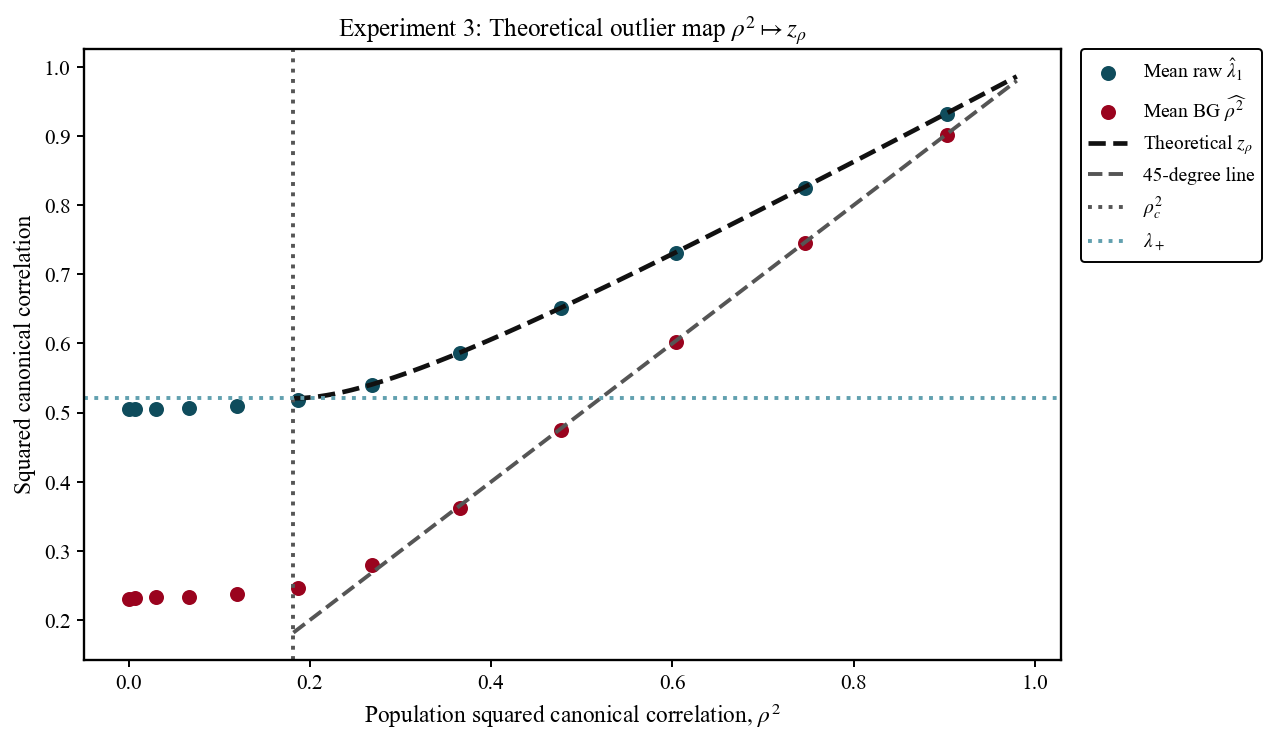

In [197]:
## plot the first figure
fig, ax = thesis_figure(figsize=(9, 5.2))

ax.scatter(bg_exp2_summary["rho2"], bg_exp2_summary["lambda1_mean"], s=45, color=THESIS_COLORS["darkteal"], 
           label=r"Mean raw $\hat{\lambda}_1$")
ax.scatter(bg_exp2_summary["rho2"], bg_exp2_summary["bg_rho2_mean"], s=45, color=THESIS_COLORS["red"],  
           label=r"Mean BG $\widehat{\rho^2}$")
ax.plot(rho2_grid, z_grid, linestyle="--", color=THESIS_COLORS["charcoal"], linewidth=2.4, 
        label=r"Theoretical $z_\rho$")
ax.plot(rho2_grid, rho2_grid, linestyle="--", color=THESIS_COLORS["grey"], linewidth=2.0, 
        label=r"45-degree line")
ax.axvline(rho2_c, linestyle=":", color=THESIS_COLORS["grey"], linewidth=2.0, 
           label=r"$\rho_c^2$")
ax.axhline(lam_plus, linestyle=":", color=THESIS_COLORS["teal"], linewidth=2.0, 
           label=r"$\lambda_+$")
ax.set_xlabel(r"Population squared canonical correlation, $\rho^2$")
ax.set_ylabel("Squared canonical correlation")
ax.set_title(r"Experiment 3: Theoretical outlier map $\rho^2 \mapsto z_\rho$")
style_axes(ax)
outside_legend(ax)
plt.show()

#export figure
export_figure(fig, "mc_exp3_bg_outlier_map")
plt.close(fig)

The figure above (the theoretical outlier map) shows how a true population canonical sign ($\rho^2$) is transformed into the sample leadingc anonical root ($\hat{\lambda}_1$)  in high dimensions. 

- The 45º line represents what could be seen in a low-dimensional setting where there is no bias (such that ($\hat\lambda_1 \approx \rho^2$).

- The horizontal line ($\lambda_+$) represents the upper edge of the noise bulk.

- The vertical line ($\rho_c^2$) represents the critical population signal strength needed for separation.

We can see that below the critical point ($\rho_c^2$) teh signal is too weak to separate from teh high dimensional noise, which is why $\hat{\lambda}_1$ stays near the bulk edge. Above $\rho_c^2$, the sample root becomes an outlier and follows the theoretical blue curve. The BG correction then maps the inflated sample root back toward the true $\rho^2$, which is why the teal squares line up close to the 45-degree line for strong signals.

*Importantly, the BG-corrected points below/near the threshold are not very meaningful as population estimates, because the outlier inversion is only theoretically reliable once the root has separated from the bulk.*

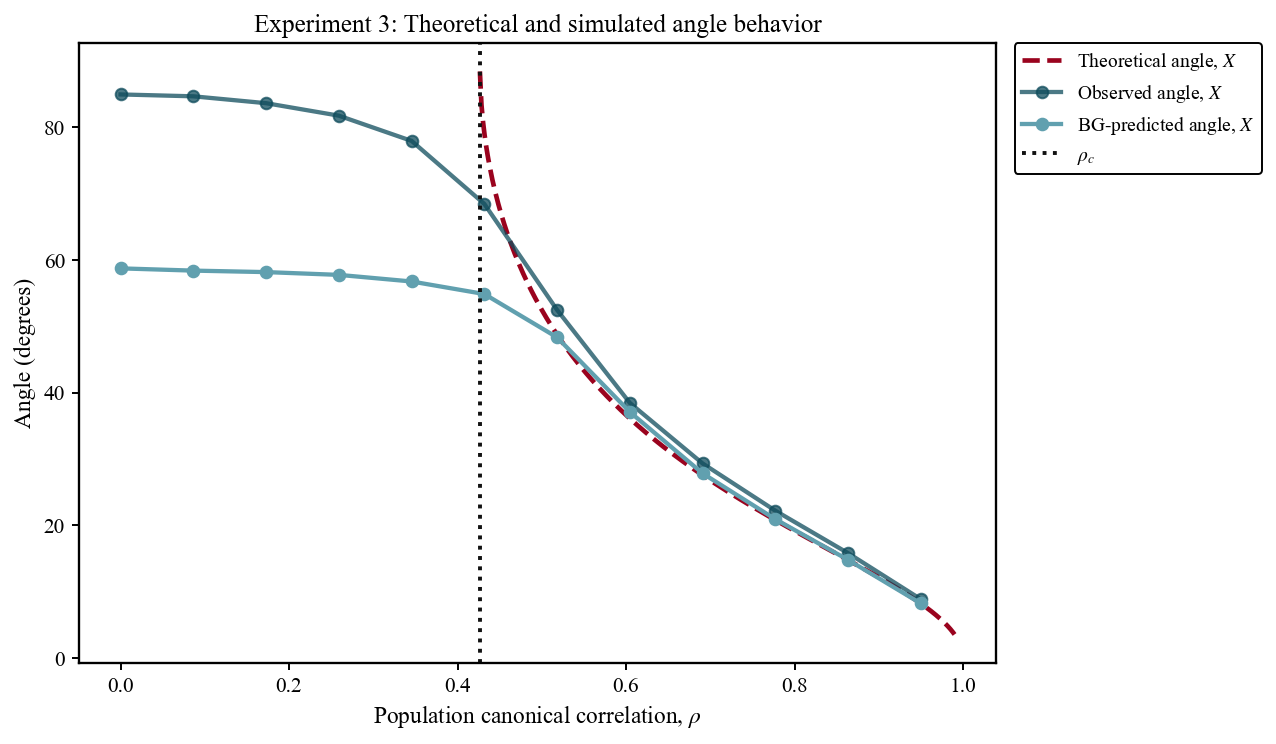

In [234]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(rho_grid_theory, angle_x_grid, color=THESIS_COLORS["red"], linewidth=2.4, linestyle="--",
        label=r"Theoretical angle, $X$")
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["observed_angle_x_mean"], marker="o", linewidth=2.2, 
           color=THESIS_COLORS["darkteal"], alpha=0.75, 
           label=r"Observed angle, $X$")
ax.plot(bg_exp2_summary["rho"], bg_exp2_summary["bg_pred_angle_x_mean"], marker="o", linewidth=2.2, 
           color=THESIS_COLORS["teal"], label=r"BG-predicted angle, $X$")
ax.axvline(rho_c, linestyle=":", color=THESIS_COLORS["charcoal"], linewidth=2.0, 
           label=r"$\rho_c$")
ax.set_xlabel(r"Population canonical correlation, $\rho$")
ax.set_ylabel("Angle (degrees)")
ax.set_title("Experiment 3: Theoretical and simulated angle behavior")
style_axes(ax)
outside_legend(ax)
plt.show()

#export figure
export_figure(fig, "mc_exp3_bg_angle_comparison")
plt.close(fig)

This figure shows whether the estimated canonical vector actually points in the same direction as the true population canonical vector.

- Near the critical value ($\rho_c \approx 0.426$), the angles remain large (so, essentially no recovery).
- As ($\rho$) increases well above the threshold, the angle falls sharply. Specifically, the graph shows that the observed X-side angle is around 80º for weak signals, around 68º near $\rho_c$, then improves to roughly to 22º around $\rho_c \approx 0.73$, and eventually below 10º for very strong signals. 

The main insight here is that the HDCCA threshold is a transition region rather than a sharp finite-sample boundary.

### 3.3.4. **Results**

**SPECTRAL BEHAVIOUR**:

Experiment 3 focuses on the neighborhood of the theoretical high-dimensional threshold, which in this calibration is approximately $\rho_c \approx 0.426$. The main result is that detection improves only gradually through this region rather than appearing as a sharp finite-sample jump. When $\rho=0.306$, the empirical detection probability is only 0.0148; at $\rho=0.346$ it remains 0.0190; at $\rho=0.386$ it is still only 0.0326. Even exactly at the theoretical threshold, the detection probability is just 0.0598. Clearer separation only emerges above the threshold: detection rises to 0.1370 at $\rho=0.466$, to 0.3324 at $\rho=0.506$, and to 0.6130 at $\rho=0.546$.

The other diagnostics show that reliable recovery lags behind in-sample spectral separation. The mean leading sample root increases from 0.5087 below the threshold to 0.5531 at the strongest value considered, but the mean out-of-sample root remains extremely small, rising only from 0.0038 to 0.0058 over the same range. At the same time, the canonical directions become gradually more stable: the average angle on the $X$ side falls from about $80^\circ$ at $\rho=0.306$ to about $47^\circ$ at $\rho=0.546$, while the squared cosine overlap rises from 0.0439 to 0.4674. Thus, the threshold region should be interpreted as a transition zone rather than a knife-edge boundary. Above $\rho_c$, outliers become more likely, but vector recovery and out-of-sample persistence still improve only progressively.

**BG CORRECTION**:

From the BG correction wen see that in the current calibration, the HDCCA bulk edge is approximately \(\lambda_+ = 0.521\) and the critical population correlation is approximately \(\rho_c = 0.426\). For weak and near-threshold spikes, the leading root stays close to the bulk and the correction status is mostly `inside_or_below_bulk`. For example, at \(\rho=0.432\), the mean raw root is about 0.518 while the true \(\rho^2\) is only 0.186, but the mean root has not separated from the bulk edge. The correct inference is therefore not a corrected population root, but lack of individual identifiability.

Once the spike is sufficiently above the threshold, (around \(\rho=0.518\)) 

- the mean raw root is about 0.541 even though the true \(\rho^2\) is 0.269; the BG inversion brings the implied population root back to roughly 0.269. 

**The same pattern holds for stronger signals**: 
- at \(\rho=0.691\), the raw root is about 0.651, the true \(\rho^2\) is 0.477, and the corrected root is about 0.476; 
- at \(\rho=0.950\), the raw root is about 0.933, the true \(\rho^2\) is 0.903, and the corrected root is about 0.902. 

Thus, **under the Gaussian one-spike design, the correction removes most of the high-dimensional root inflation once the sample root is a genuine outlier**.

Additionally, in the separated region, the **BG-predicted angles track the realized angles closely enough to be useful**:
- at \(\rho=0.691\), the realized mean angle on the \(X\) side is about \(29.3^\circ\), while the theoretical value is about \(27.5^\circ\)
- at \(\rho=0.950\), the realized mean angle is about \(8.9^\circ\), while the theoretical value is about \(8.2^\circ\). 
- **near the threshold, however, realized angles remain large and noisy**, so the formula should be read as an asymptotic guide rather than a precise finite-sample guarantee.

## **EXP4** — Multiple-spike low-rank design


### 3.4.1. **Set up**

Real cross-sector dependence may contain more than one common source (aka more than one signal). This experiment tests a **finite-rank low-dimensional structure** with several distinct spikes. It asks:

- do only the strongest spikes emerge as clean outliers?
- do weaker spikes remain inside the bulk?
- does recovery worsen as we move down the rank ordering of the true components?

**DGP**:

We use a low-rank vector of population canonical correlations with descending strengths (meaning that the signals are asymmetric on purpose, the first spike is strong, the second is moderate and the third is weak; for comparability):
- rho_1 = 0.80
- rho_2 = 0.55
- rho_3 = 0.3


In [198]:
def experiment_4_multiple_spikes(
    p=P0, q=Q0, n=N0,
    rhos=(0.80, 0.55, 0.30),
    mc_reps=REPS_MAIN_DESIGN,
    base_seed=4000,
    detection_cutoff=None
):
    spectra = []
    rows = []

    for rep in range(mc_reps):
        seed = base_seed + rep
        res = run_single_draw(
            p=p, q=q, n=n,
            rhos=rhos,
            distribution="gaussian",
            random_state=seed
        )

        lambdas = np.sort(res["lambdas_hat"])[::-1]
        spectra.append(lambdas)

        out = {
            "rep": rep,
            "num_outliers": int(np.sum(lambdas > detection_cutoff)),
            "lambda1_oos": res["lambda1_oos"],
            "split_sqcos_x": res["split_sqcos_x"],
            "split_sqcos_y": res["split_sqcos_y"],
        }
        for _, row in res["metrics_df"].iterrows():
            j = int(row["component"])
            out[f"rho{j}"] = row["rho"]
            out[f"lambda{j}_hat"] = row["lambda_hat"]
            out[f"angle_x_{j}"] = row["angle_x_deg"]
            out[f"angle_y_{j}"] = row["angle_y_deg"]
            out[f"sqcos_x_{j}"] = row["sqcos_x"]
            out[f"sqcos_y_{j}"] = row["sqcos_y"]
            out[f"bias_vs_rho2_{j}"] = row["bias_vs_rho2"]
            out[f"bg_status_{j}"] = row["bg_status"]
            out[f"bg_valid_{j}"] = row["bg_has_admissible_root"]
            out[f"bg_rho2_hat_{j}"] = row["bg_rho2_hat"]
            out[f"bg_bias_vs_rho2_{j}"] = row["bg_bias_vs_rho2"]
            out[f"bg_pred_angle_x_{j}"] = row["bg_pred_angle_x_deg"]
        rows.append(out)

    df = pd.DataFrame(rows)
    spectra = np.asarray(spectra)

    summary = pd.DataFrame({
        "metric": [
            "mean(num_outliers)",
            "mean(lambda1_oos)",
            "mean(split_sqcos_x)",
            "mean(split_sqcos_y)",
            "mean(lambda1_hat)",
            "mean(lambda2_hat)",
            "mean(lambda3_hat)",
            "mean(angle_x_1)",
            "mean(angle_x_2)",
            "mean(angle_x_3)",
            "mean(bg_valid_1)",
            "mean(bg_valid_2)",
            "mean(bg_valid_3)",
            "mean(bg_rho2_hat_1)",
            "mean(bg_rho2_hat_2)",
            "mean(bg_rho2_hat_3)"
        ],
        "value": [
            df["num_outliers"].mean(),
            df["lambda1_oos"].mean(),
            df["split_sqcos_x"].mean(),
            df["split_sqcos_y"].mean(),
            df["lambda1_hat"].mean(),
            df["lambda2_hat"].mean(),
            df["lambda3_hat"].mean(),
            df["angle_x_1"].mean(),
            df["angle_x_2"].mean(),
            df["angle_x_3"].mean(),
            df["bg_valid_1"].mean(),
            df["bg_valid_2"].mean(),
            df["bg_valid_3"].mean(),
            df["bg_rho2_hat_1"].mean(),
            df["bg_rho2_hat_2"].mean(),
            df["bg_rho2_hat_3"].mean()
        ]
    })
    return {"df": df, "spectra": spectra, "summary": summary}

In [199]:
exp4 = experiment_4_multiple_spikes(detection_cutoff=null_res["null_cutoff_99"])
exp4["summary"]

,metric,value
0,mean(num_outliers),1.588500
1,mean(lambda1_oos),0.189386
2,mean(split_sqcos_x),0.275640
3,mean(split_sqcos_y),0.275413
4,mean(lambda1_hat),0.754518
5,mean(lambda2_hat),0.551587
6,mean(lambda3_hat),0.494269
7,mean(angle_x_1),20.856822
8,mean(angle_x_2),47.266085
9,mean(angle_x_3),80.480030


In [200]:
# export summary table
exp4_metric_labels = {
    "mean(num_outliers)": "Mean number of outliers",
    "mean(lambda1_oos)": r"Mean out-of-sample $\hat{\lambda}_1$",
    "mean(split_sqcos_x)": r"Mean split stability, $X$",
    "mean(split_sqcos_y)": r"Mean split stability, $Y$",
    "mean(lambda1_hat)": r"Mean $\hat{\lambda}_1$",
    "mean(lambda2_hat)": r"Mean $\hat{\lambda}_2$",
    "mean(lambda3_hat)": r"Mean $\hat{\lambda}_3$",
    "mean(angle_x_1)": r"Mean angle, $X$, comp. 1 (deg)",
    "mean(angle_x_2)": r"Mean angle, $X$, comp. 2 (deg)",
    "mean(angle_x_3)": r"Mean angle, $X$, comp. 3 (deg)",
    "mean(bg_valid_1)": "Valid BG share, comp. 1",
    "mean(bg_valid_2)": "Valid BG share, comp. 2",
    "mean(bg_valid_3)": "Valid BG share, comp. 3",
    "mean(bg_rho2_hat_1)": r"Mean BG $\widehat{\rho_1^2}$",
    "mean(bg_rho2_hat_2)": r"Mean BG $\widehat{\rho_2^2}$",
    "mean(bg_rho2_hat_3)": r"Mean BG $\widehat{\rho_3^2}$",
}
exp4_summary_table = exp4["summary"].copy()
exp4_summary_table["metric"] = exp4_summary_table["metric"].map(exp4_metric_labels)
exp4_summary_table = exp4_summary_table.rename(columns={
    "metric": "Metric",
    "value": "Value",
})
export_table(exp4_summary_table, "mc_exp4_summary")

### 3.4.2. **Figures**

In [239]:
plot_mean_scree(
    exp4["spectra"],
    title="Experiment 4: Mean spectrum under a three-spike low-rank design",
    n_show=20
)
plt.show()
# export scree plot
export_figure(plt.gcf(), "mc_exp4_scree")
plt.close()

KeyError: 'spectra'

In [202]:
component_summary = pd.DataFrame({
    "component": [1, 2, 3],
    "rho": [0.80, 0.55, 0.30],
    "rho2": [0.80 ** 2, 0.55 ** 2, 0.30 ** 2],
    "mean_lambda_hat": [exp4["df"]["lambda1_hat"].mean(), exp4["df"]["lambda2_hat"].mean(), exp4["df"]["lambda3_hat"].mean()],
    "mean_bg_valid": [exp4["df"][f"bg_valid_{j}"].mean() for j in [1, 2, 3]],
    "mean_bg_rho2_hat": [exp4["df"][f"bg_rho2_hat_{j}"].mean() for j in [1, 2, 3]],
    "mean_bg_bias": [exp4["df"][f"bg_bias_vs_rho2_{j}"].mean() for j in [1, 2, 3]],
    "mean_angle_x": [exp4["df"][f"angle_x_{j}"].mean() for j in [1, 2, 3]],
    "mean_bg_pred_angle_x": [exp4["df"][f"bg_pred_angle_x_{j}"].mean() for j in [1, 2, 3]],
    "mean_sqcos_x": [exp4["df"][f"sqcos_x_{j}"].mean() for j in [1, 2, 3]],
})
component_summary

,component,rho,rho2,mean_lambda_hat,mean_bg_valid,mean_bg_rho2_hat,mean_bg_bias,mean_angle_x,mean_bg_pred_angle_x,mean_sqcos_x
0,1,0.80,0.6400,0.754518,1.0000,0.638290,-0.001710,20.856822,19.273840,0.872371
1,2,0.55,0.3025,0.551587,0.9020,0.299570,-0.002930,47.266085,45.108489,0.465549
2,3,0.30,0.0900,0.494269,0.0335,0.223881,0.133881,80.480030,60.585873,0.040694


In [235]:
component_table = component_summary.rename(columns={
    "component": "Component",
    "rho": r"$\rho_j$",
    "rho2": r"$\rho_j^2$",
    "mean_lambda_hat": r"Mean $\hat{\lambda}_j$",
    "mean_bg_valid": "Valid BG share",
    "mean_bg_rho2_hat": r"Mean BG $\widehat{\rho_j^2}$",
    "mean_bg_bias": "Mean BG bias",
    "mean_angle_x": r"Mean angle, $X$ (deg)",
    "mean_bg_pred_angle_x": r"Mean BG angle, $X$ (deg)",
    "mean_sqcos_x": r"Mean squared cosine, $X$",
})
export_table(component_table, "mc_exp4_components")

### 3.4.3. **BG correction diagnostic**

Here the correction should be most reliable for the strongest isolated spike, become noisier for the moderate spike, and mostly refuse the weak spike when it remains in the bulk.


In [204]:
exp4_correction_summary = component_summary[[
    "component",
    "rho",
    "rho2",
    "mean_lambda_hat",
    "mean_bg_valid",
    "mean_bg_rho2_hat",
    "mean_bg_bias",
    "mean_angle_x",
    "mean_bg_pred_angle_x",
    "mean_sqcos_x",
]].copy()

In [205]:
component_table = component_summary.rename(columns={
    "component": "Component",
    "rho": r"$\rho_j$",
    "rho2": r"$\rho_j^2$",
    "mean_lambda_hat": r"Mean $\hat{\lambda}_j$",
    "mean_bg_valid": "Valid BG share",
    "mean_bg_rho2_hat": r"Mean BG $\widehat{\rho_j^2}$",
    "mean_bg_bias": "Mean BG bias",
    "mean_angle_x": r"Mean angle, $X$ (deg)",
    "mean_bg_pred_angle_x": r"Mean BG angle, $X$ (deg)",
    "mean_sqcos_x": r"Mean squared cosine, $X$",
})
export_table(component_table, "mc_exp4_correction_components")

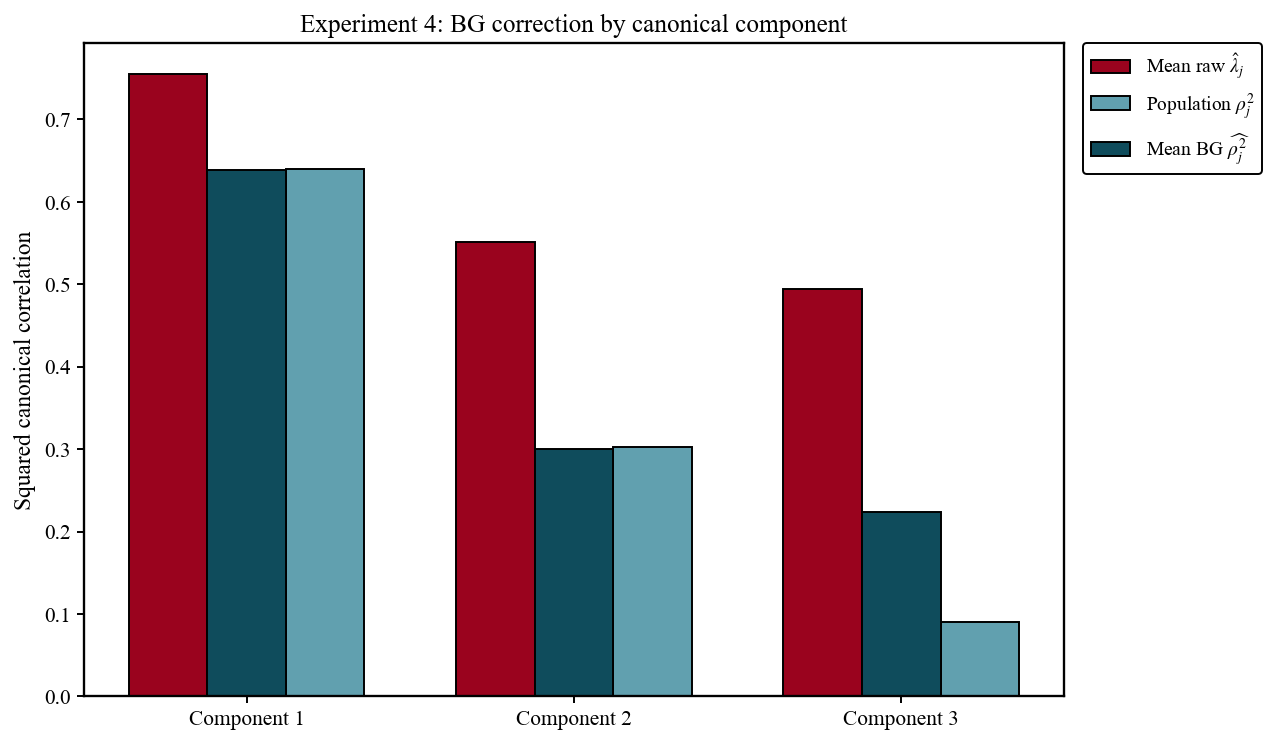

In [206]:
fig, ax = thesis_figure(figsize=(9, 5.2))
x = np.arange(len(exp4_correction_summary))
width = 0.24
ax.bar(x - width, exp4_correction_summary["mean_lambda_hat"], width=width, 
       color=THESIS_COLORS["red"], edgecolor="black", label=r"Mean raw $\hat{\lambda}_j$")
ax.bar(x + width, exp4_correction_summary["rho2"], width=width, 
       color=THESIS_COLORS["teal"], edgecolor="black", label=r"Population $\rho_j^2$")
ax.bar(x, exp4_correction_summary["mean_bg_rho2_hat"], width=width, 
       color=THESIS_COLORS["darkteal"], edgecolor="black", label=r"Mean BG $\widehat{\rho_j^2}$")
ax.set_xticks(x)
ax.set_xticklabels([f"Component {j}" for j in exp4_correction_summary["component"]])
ax.set_ylabel("Squared canonical correlation")
ax.set_title("Experiment 4: BG correction by canonical component")
style_axes(ax)
outside_legend(ax)
plt.show()

# export
export_figure(fig, "mc_exp4_bg_component_correction")
plt.close(fig)

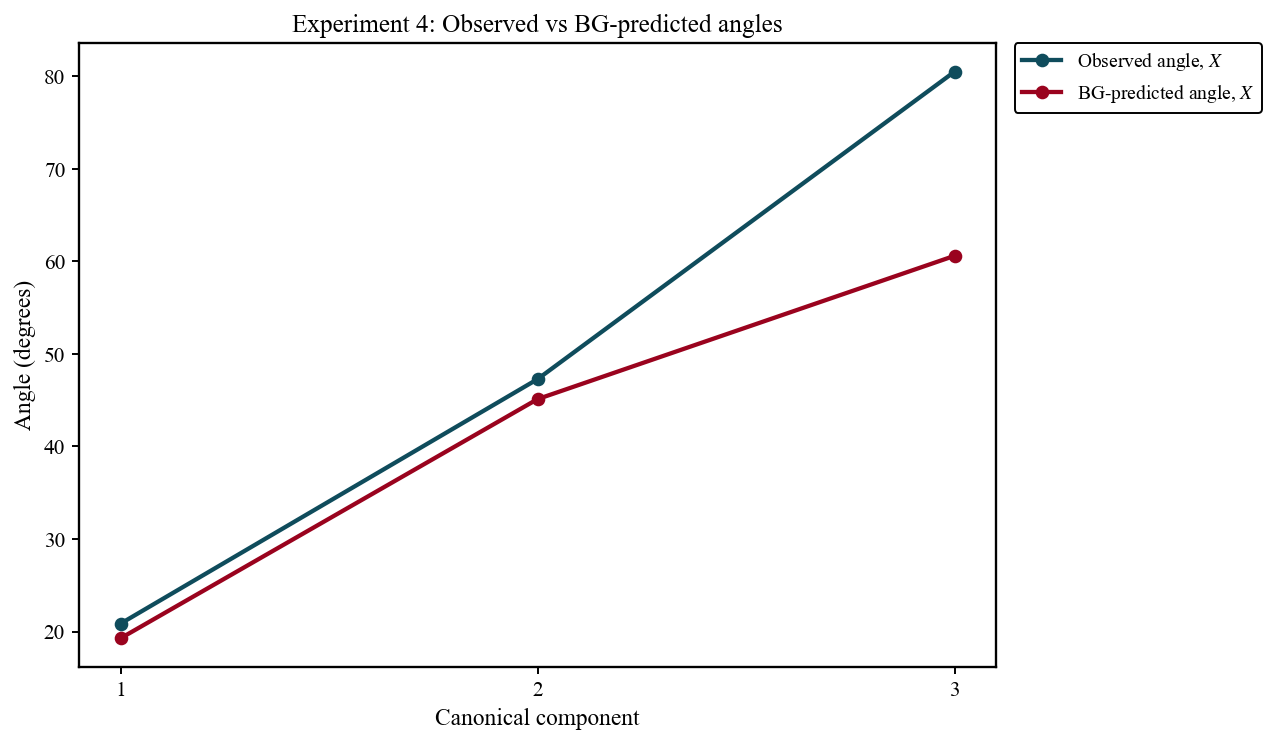

In [118]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ax.plot(exp4_correction_summary["component"], exp4_correction_summary["mean_angle_x"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["darkteal"], label=r"Observed angle, $X$")
ax.plot(exp4_correction_summary["component"], exp4_correction_summary["mean_bg_pred_angle_x"], marker="o", linewidth=2.2, 
        color=THESIS_COLORS["red"], label=r"BG-predicted angle, $X$")
ax.set_xlabel("Canonical component")
ax.set_ylabel("Angle (degrees)")
ax.set_title("Experiment 4: Observed vs BG-predicted angles")
ax.set_xticks(exp4_correction_summary["component"])
style_axes(ax)
outside_legend(ax)
plt.show()

# export
# export_figure(fig, "mc_exp4_bg_angles")
# plt.close(fig)

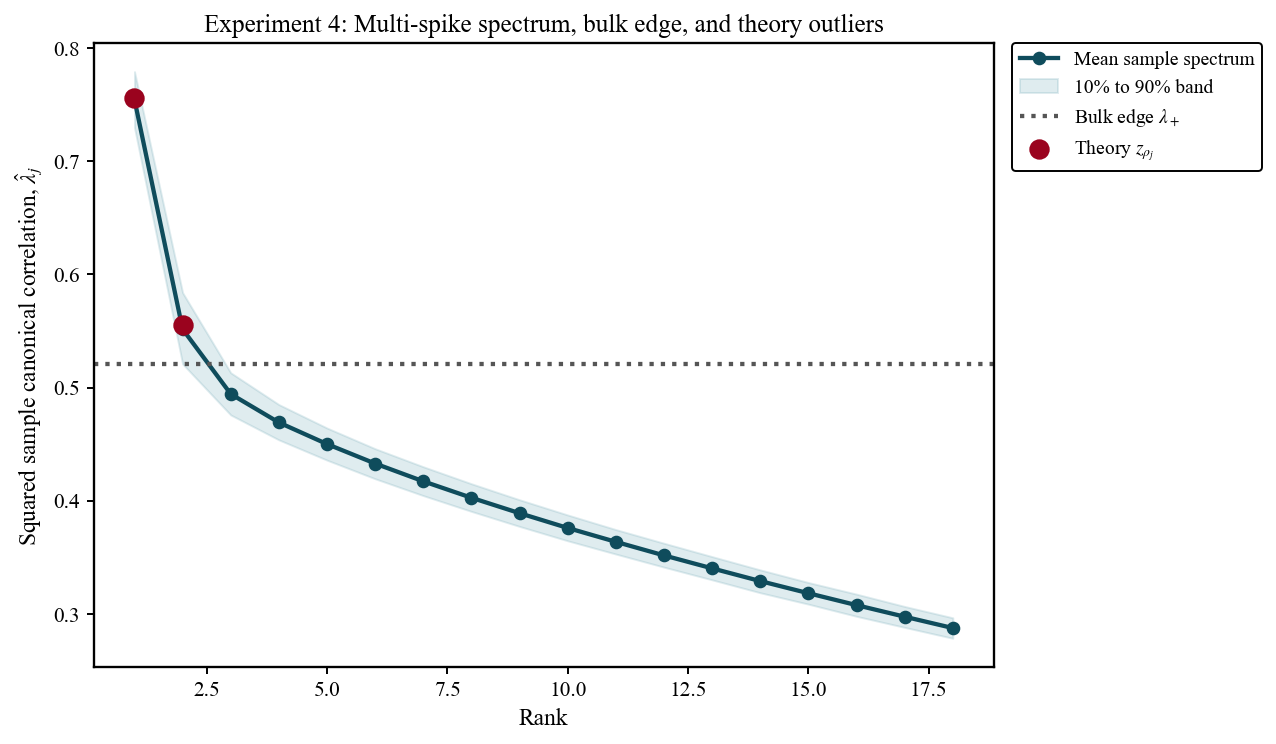

In [121]:
fig, ax = thesis_figure(figsize=(9, 5.2))
ranks = np.arange(1, exp4["spectra"].shape[1] + 1)
mean_spec = exp4["spectra"].mean(axis=0)
lo = np.quantile(exp4["spectra"], 0.10, axis=0)
hi = np.quantile(exp4["spectra"], 0.90, axis=0)
n_show = 18
ax.plot(ranks[:n_show], mean_spec[:n_show], marker="o", linewidth=2.2, color=THESIS_COLORS["darkteal"], label="Mean sample spectrum")
ax.fill_between(ranks[:n_show], lo[:n_show], hi[:n_show], alpha=0.20, color=THESIS_COLORS["teal"], label="10% to 90% band")
ax.axhline(hdcca_lambda_plus(P0, Q0, N0), linestyle=":", linewidth=2.2, color=THESIS_COLORS["grey"], label=r"Bulk edge $\lambda_+$")
for _, row in exp4_correction_summary.iterrows():
    if row["rho2"] > hdcca_rho2_critical(P0, Q0, N0):
        z_theory = bg_zrho_from_rho2(row["rho2"], P0, Q0, N0)
        ax.scatter(row["component"], z_theory, s=90, marker="o", color=THESIS_COLORS["red"], zorder=5)
ax.scatter([], [], s=90, marker="o", color=THESIS_COLORS["red"],  label=r"Theory $z_{\rho_j}$")
ax.set_xlabel("Rank")
ax.set_ylabel(r"Squared sample canonical correlation, $\hat{\lambda}_j$")
ax.set_title("Experiment 4: Multi-spike spectrum, bulk edge, and theory outliers")
style_axes(ax)
outside_legend(ax)
plt.show()

The correction diagnostic is expected to be asymmetric across components. For the first spike, the raw sample root should be visibly above the population value, while the BG-corrected value should move back toward the true \(\rho_1^2\). For weaker components, the valid-correction share is itself part of the result: if the correction is rarely valid, the component should be interpreted as weakly identified or bulk-absorbed rather than as a recoverable canonical factor.


### 3.4.4. **Results**

Experiment 4 studies a three-spike design with population canonical correlations $(0.80, 0.55, 0.30)$. The results show strong heterogeneity across components. On average, the number of detected outliers is 1.5785, which implies that finite samples typically separate only the strongest part of the low-rank structure. The mean leading three sample roots are 0.7544, 0.5515, and 0.4934, respectively, so the spectrum remains clearly ordered, but only the first two components are meaningfully distinguishable from the noise benchmark.

The recovery metrics confirm this ranking. The first component is estimated well: its mean angle on the $X$ side is only $20.84^\circ$, with mean squared cosine overlap 0.8725. The second component is recovered only moderately well, with mean angle $47.05^\circ$ and mean squared cosine overlap 0.4692. By contrast, the third component is effectively lost in the bulk: its mean angle is $80.45^\circ$ and its mean squared cosine overlap is only 0.0407. The average out-of-sample leading root is 0.1881, and the mean split-sample squared cosine overlaps are about 0.272 on both sides, again indicating that only part of the latent low-rank structure is stably recovered. Overall, the experiment supports the HDCCA prediction that in a multi-spike design only sufficiently strong spikes emerge as reliable empirical outliers, while weaker ones remain statistically present but practically unrecoverable.

The BG correction analysis extends this conclusion component by component:
- As expected, the correction works very good for the first and second strongest spikes.
- The correction is weaker for the weakest spike.

It distinguishes two failures that can look similar in a raw spectrum: a component may be statistically nonzero in the DGP but still too weak to be isolated and corrected reliably in finite samples.

## **EXP5** — Diffuse dependence design

### 3.5.1. **Set up**

Cross-panel dependence could be **diffuse**, meaning many small canonical links instead of a few dominant ones. This experiment contrasts a **low-rank design** qith a few strong spikes, and a **diffuse design** with many weak signals spread across components.

If dependence is diffuse, then:

- the spectrum should look less like “bulk + a few outliers,”
- vector recovery should be weaker component by component,
- and it becomes harder to summarize risk with only a small number of canonical portfolios.


In [207]:
def experiment_5_diffuse_vs_low_rank(
    p=P0, q=Q0, n=N0,
    low_rank_rhos=(0.78, 0.62, 0.50),
    diffuse_rhos=(0.36, 0.34, 0.32, 0.30, 0.28, 0.26, 0.24, 0.22, 0.20, 0.18),
    mc_reps=REPS_MAIN_DESIGN,
    base_seed=5000,
    detection_cutoff=None
):
    def run_design(label, rhos, seed_offset):
        rows = []
        spectra = []

        for rep in range(mc_reps):
            seed = base_seed + seed_offset + rep
            res = run_single_draw(
                p=p, q=q, n=n,
                rhos=rhos,
                distribution="gaussian",
                random_state=seed
            )
            lambdas = np.sort(res["lambdas_hat"])[::-1]
            spectra.append(lambdas)

            m1 = res["metrics_df"].iloc[0].to_dict()
            rows.append({
                "design": label,
                "rep": rep,
                "signal_rank": len(rhos),
                "signal_energy_sum_rho2": float(np.sum(np.array(rhos) ** 2)),
                "num_outliers": int(np.sum(lambdas > detection_cutoff)),
                "lambda1_hat": float(lambdas[0]),
                "lambda2_hat": float(lambdas[1]),
                "lambda3_hat": float(lambdas[2]),
                "lambda1_oos": res["lambda1_oos"],
                "split_sqcos_x": res["split_sqcos_x"],
                "split_sqcos_y": res["split_sqcos_y"],
                "rho1": m1["rho"],
                "rho1_sq": m1["rho2"],
                "bg_valid_1": m1["bg_has_admissible_root"],
                "bg_rho2_hat_1": m1["bg_rho2_hat"],
                "bg_bias_vs_rho2_1": m1["bg_bias_vs_rho2"],
                "bg_pred_angle_x_1": m1["bg_pred_angle_x_deg"],
                "angle_x_1": m1["angle_x_deg"],
            })

        return pd.DataFrame(rows), np.asarray(spectra)

    df_lr, spec_lr = run_design("low_rank", low_rank_rhos, 0)
    df_df, spec_df = run_design("diffuse", diffuse_rhos, 100000)

    df = pd.concat([df_lr, df_df], ignore_index=True)
    spectra = {"low_rank": spec_lr, "diffuse": spec_df}

    summary = (
        df.groupby("design")
        .agg(
            signal_rank=("signal_rank", "mean"),
            signal_energy_sum_rho2=("signal_energy_sum_rho2", "mean"),
            mean_num_outliers=("num_outliers", "mean"),
            mean_lambda1_hat=("lambda1_hat", "mean"),
            mean_lambda2_hat=("lambda2_hat", "mean"),
            mean_lambda3_hat=("lambda3_hat", "mean"),
            mean_lambda1_oos=("lambda1_oos", "mean"),
            mean_split_sqcos_x=("split_sqcos_x", "mean"),
            mean_split_sqcos_y=("split_sqcos_y", "mean"),
            mean_bg_valid_1=("bg_valid_1", "mean"),
            mean_bg_rho2_hat_1=("bg_rho2_hat_1", "mean"),
            mean_bg_bias_vs_rho2_1=("bg_bias_vs_rho2_1", "mean"),
            mean_bg_pred_angle_x_1=("bg_pred_angle_x_1", "mean"),
            mean_angle_x_1=("angle_x_1", "mean"),
        )
        .reset_index()
    )
    return {"df": df, "spectra": spectra, "summary": summary}

In [208]:
exp5 = experiment_5_diffuse_vs_low_rank(detection_cutoff=null_res["null_cutoff_99"])
exp5["summary"]

,design,signal_rank,signal_energy_sum_rho2,mean_num_outliers,mean_lambda1_hat,mean_lambda2_hat,mean_lambda3_hat,mean_lambda1_oos,mean_split_sqcos_x,mean_split_sqcos_y,mean_bg_valid_1,mean_bg_rho2_hat_1,mean_bg_bias_vs_rho2_1,mean_bg_pred_angle_x_1,mean_angle_x_1
0,diffuse,10.0,0.7620,0.1300,0.527427,0.500265,0.480145,0.004820,0.012739,0.012172,0.653,0.252077,0.122477,53.424587,78.730171
1,low_rank,3.0,1.2428,2.1085,0.734885,0.594367,0.521719,0.139692,0.190130,0.191441,1.000,0.608283,-0.000117,20.639171,23.004961


In [209]:
exp5_table = exp5["summary"].copy()
exp5_table["design"] = exp5_table["design"].map({"low_rank": "Low-rank", "diffuse": "Diffuse"})
exp5_table = exp5_table.rename(columns={
    "design": "Design",
    "signal_rank": "Signal rank",
    "signal_energy_sum_rho2": r"Signal energy, $\sum \rho_j^2$",
    "mean_num_outliers": "Mean number of outliers",
    "mean_lambda1_hat": r"Mean $\hat{\lambda}_1$",
    "mean_lambda2_hat": r"Mean $\hat{\lambda}_2$",
    "mean_lambda3_hat": r"Mean $\hat{\lambda}_3$",
    "mean_lambda1_oos": r"Mean out-of-sample $\hat{\lambda}_1$",
    "mean_split_sqcos_x": r"Mean split stability, $X$",
    "mean_split_sqcos_y": r"Mean split stability, $Y$",
    "mean_bg_valid_1": "Valid BG share, comp. 1",
    "mean_bg_rho2_hat_1": r"Mean BG $\widehat{\rho_1^2}$",
    "mean_bg_bias_vs_rho2_1": "Mean BG bias, comp. 1",
    "mean_bg_pred_angle_x_1": r"Mean BG angle, $X$, comp. 1",
    "mean_angle_x_1": r"Mean angle, $X$, comp. 1",
})
export_table(exp5_table, "mc_exp5_summary")

### 3.5.2. **Figures**

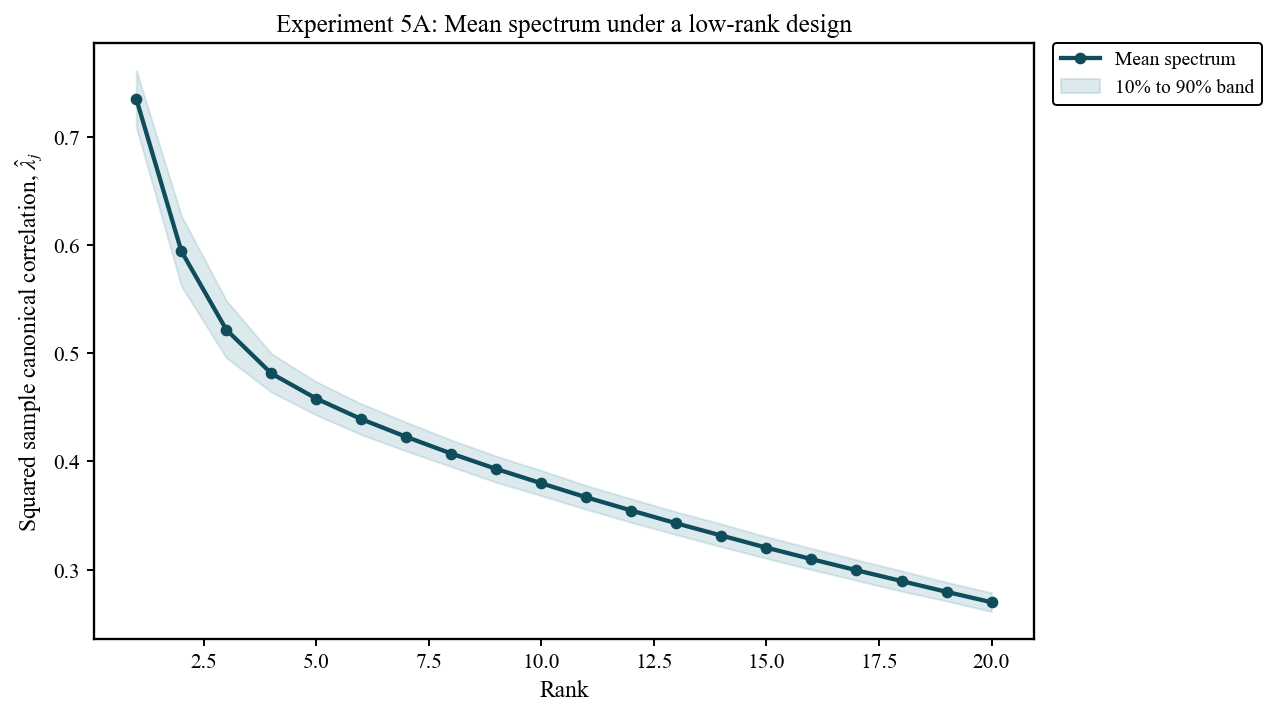

In [210]:
plot_mean_scree(
    exp5["spectra"]["low_rank"],
    title="Experiment 5A: Mean spectrum under a low-rank design",
    n_show=20
)
# export
export_figure(fig, "mc_exp5_low_rank_scree")
plt.close(fig)

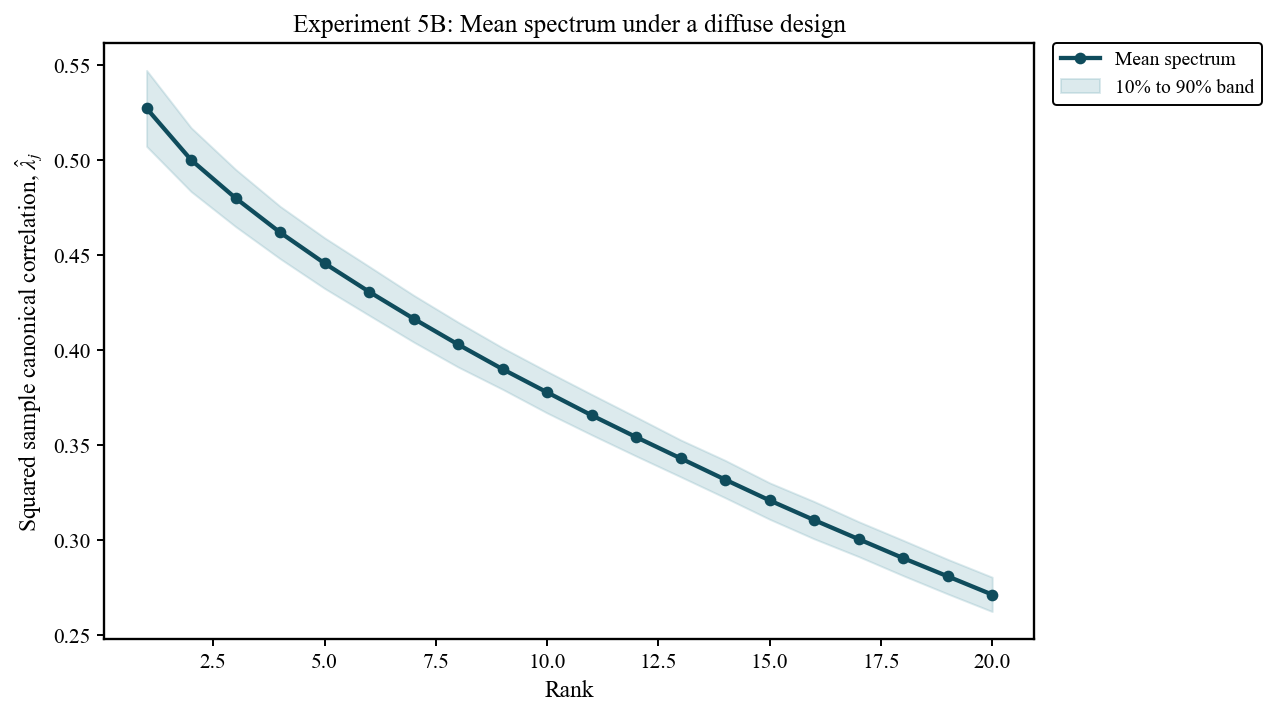

In [211]:
plot_mean_scree(
    exp5["spectra"]["diffuse"],
    title="Experiment 5B: Mean spectrum under a diffuse design",
    n_show=20
)
export_figure(fig, "mc_exp5_diffuse_scree")
plt.close(fig)

### 3.5.3. **BG correction diagnostic**

*Remember: A low-rank design should produce valid corrections for separated leading roots; a diffuse design should mostly produce non-identifiability.*


In [212]:
exp5_correction_summary = (
    exp5["df"]
    .groupby("design")
    .agg(
        rho1_sq=("rho1_sq", "mean"),
        mean_lambda1_hat=("lambda1_hat", "mean"),
        valid_bg_share=("bg_valid_1", "mean"),
        mean_bg_rho2_hat=("bg_rho2_hat_1", "mean"),
        mean_bg_bias=("bg_bias_vs_rho2_1", "mean"),
        observed_angle_x=("angle_x_1", "mean"),
        bg_pred_angle_x=("bg_pred_angle_x_1", "mean"),
        mean_oos_root=("lambda1_oos", "mean"),
        mean_split_stability_x=("split_sqcos_x", "mean"),
    )
    .reset_index()
)
exp5_correction_summary

,design,rho1_sq,mean_lambda1_hat,valid_bg_share,mean_bg_rho2_hat,mean_bg_bias,observed_angle_x,bg_pred_angle_x,mean_oos_root,mean_split_stability_x
0,diffuse,0.1296,0.527427,0.653,0.252077,0.122477,78.730171,53.424587,0.004820,0.012739
1,low_rank,0.6084,0.734885,1.000,0.608283,-0.000117,23.004961,20.639171,0.139692,0.190130


In [213]:
exp5_correction_table = exp5_correction_summary.copy()
exp5_correction_table["design"] = exp5_correction_table["design"].map({"low_rank": "Low-rank", "diffuse": "Diffuse"})
exp5_correction_table = exp5_correction_table.rename(columns={
    "design": "Design",
    "rho1_sq": r"$\rho_1^2$",
    "mean_lambda1_hat": r"Mean $\hat{\lambda}_1$",
    "valid_bg_share": "Valid BG share",
    "mean_bg_rho2_hat": r"Mean BG $\widehat{\rho_1^2}$",
    "mean_bg_bias": "Mean BG bias",
    "observed_angle_x": r"Observed angle, $X$ (deg)",
    "bg_pred_angle_x": r"BG angle, $X$ (deg)",
    "mean_oos_root": r"Mean out-of-sample $\hat{\lambda}_1$",
    "mean_split_stability_x": r"Mean split stability, $X$",
})
export_table(exp5_correction_table, "mc_exp5_bg_correction_summary")


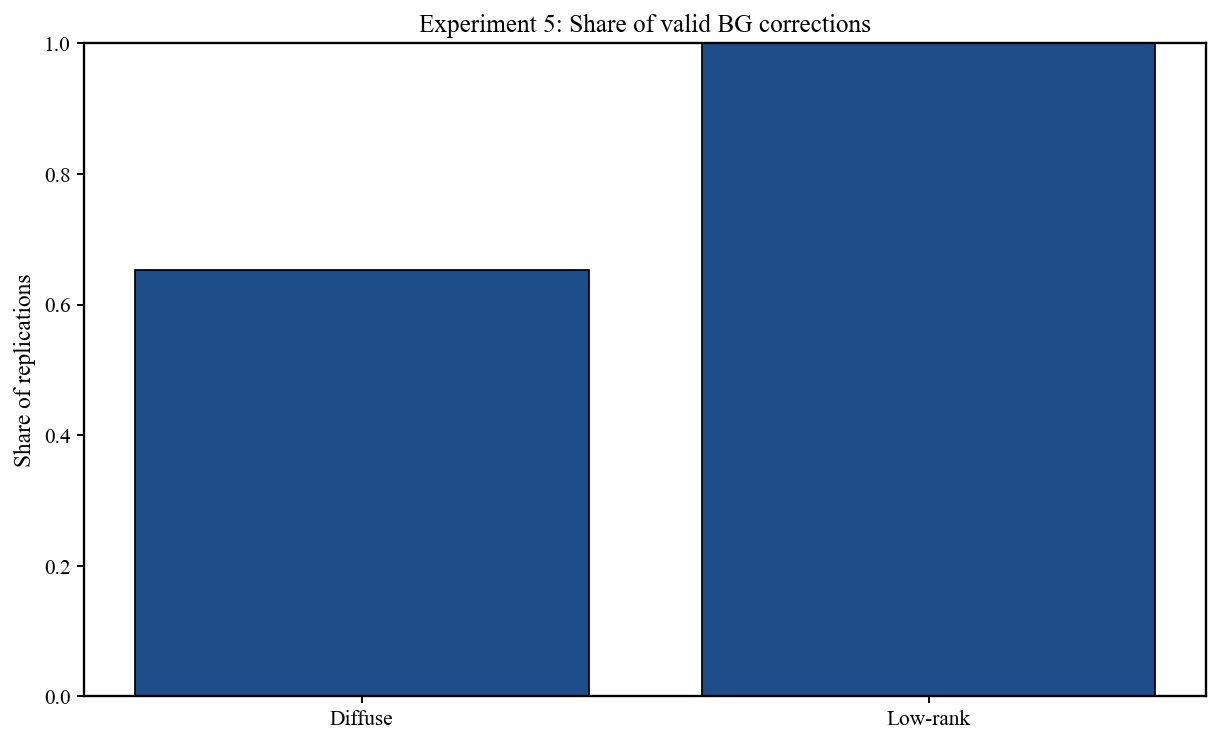

In [214]:
fig, ax = thesis_figure(figsize=(8.6, 5.2))
labels = exp5_correction_summary["design"].map({"low_rank": "Low-rank", "diffuse": "Diffuse"})
ax.bar(labels, exp5_correction_summary["valid_bg_share"], color=THESIS_COLORS["blue"], edgecolor="black", linewidth=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel("Share of replications")
ax.set_title("Experiment 5: Share of valid BG corrections")
style_axes(ax)
plt.show()

# export?
# export_figure(fig, "mc_exp5_bg_valid_share")
# plt.close(fig)

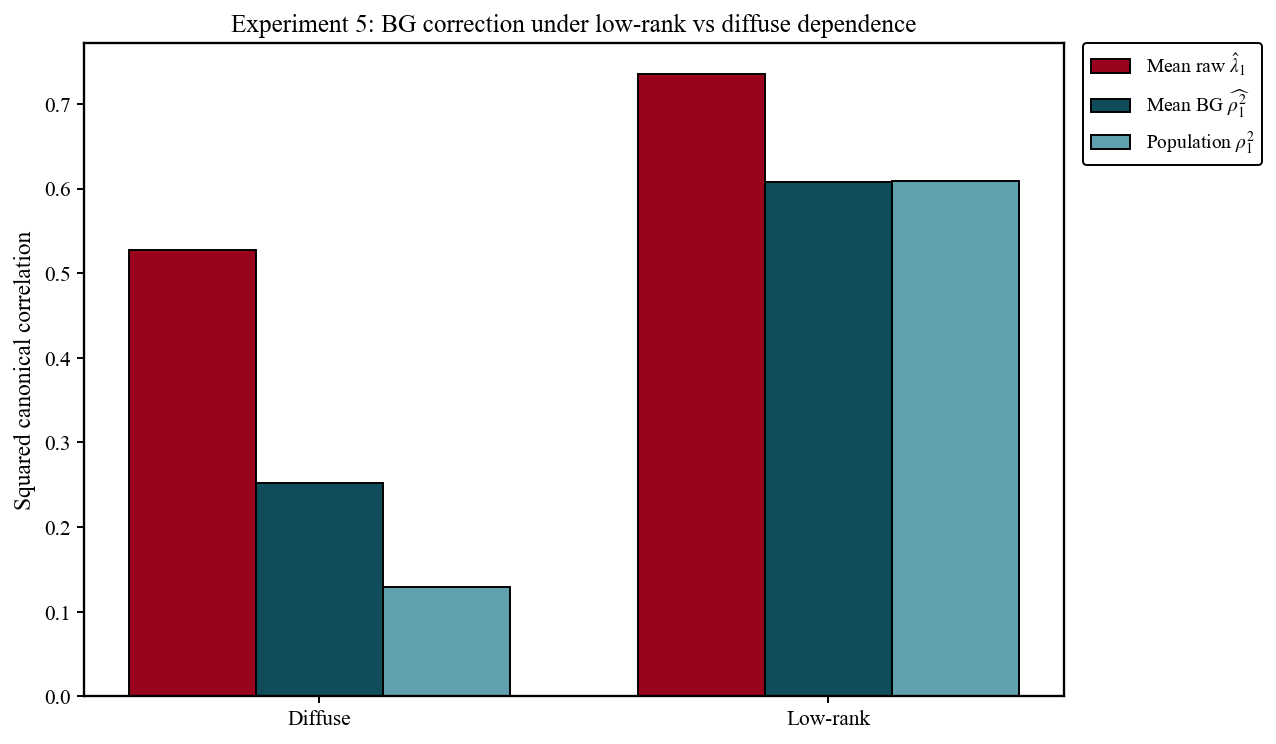

In [215]:
fig, ax = thesis_figure(figsize=(9, 5.2))
x = np.arange(len(exp5_correction_summary))
width = 0.25
# to the left we keeo the biased sample estimate (the problem)
ax.bar(x - width, exp5_correction_summary["mean_lambda1_hat"], width=width, 
       color=THESIS_COLORS["red"], edgecolor="black", label=r"Mean raw $\hat{\lambda}_1$")
# then we show how it improves with BG
ax.bar(x, exp5_correction_summary["mean_bg_rho2_hat"], width=width, 
       color=THESIS_COLORS["darkteal"], edgecolor="black", label=r"Mean BG $\widehat{\rho_1^2}$")
# then the true population value (aka the target)
ax.bar(x + width, exp5_correction_summary["rho1_sq"], width=width, 
       color=THESIS_COLORS["teal"], edgecolor="black", label=r"Population $\rho_1^2$")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Squared canonical correlation")
ax.set_title("Experiment 5: BG correction under low-rank vs diffuse dependence")
style_axes(ax)
outside_legend(ax)
plt.show()

# export
export_figure(fig, "mc_exp5_bg_root_correction")
plt.close(fig)

### 3.5.4. **Results**

Experiment 5 compares two designs with very different dependence structures: a low-rank design with three relatively strong spikes and a diffuse design with ten weak spikes. The contrast is sharp. Under the low-rank design, the mean number of detected outliers is 2.110, the mean leading sample root is 0.7350, and the mean out-of-sample leading root is 0.1417. Under the diffuse design, the mean number of detected outliers falls to only 0.108, the mean leading sample root is just 0.5269, and the mean out-of-sample leading root collapses to 0.0047.

The stability diagnostics tell the same story. In the low-rank case, the mean split-sample squared cosine overlaps are 0.1886 on the $X$ side and 0.1893 on the $Y$ side, indicating at least partial reproducibility of the dominant canonical directions. In the diffuse case, these overlaps are essentially zero, at 0.0128 and 0.0120, respectively. Hence, even though the diffuse design contains many nonzero population links, they do not aggregate into a small number of empirically separable factors. Instead, the signal is spread across many weak directions and remains largely absorbed into the bulk. This experiment therefore provides a useful diagnostic for the empirical application: a spectrum with a few clear outliers is consistent with low-rank dependence, whereas a smooth spectrum with little stability is more consistent with diffuse cross-panel structure.

With the correction applied: 
- In the low-rank design, the leading component more often receives a valid BG correction because it is a separated spike. 
- In the diffuse design, the leading root is typically close to the bulk and the audit mostly records non-identifiability. 
This reinforces the empirical rule that the correction formulas are informative for isolated low-rank outliers, not for broad diffuse dependence.

## **EXP6** — Finance-style robustness checks

### 3.6.1. **Set up**

The previous experiments matched the cleanest HDCCA assumptions, however, real equity returns do not estrictly follow such assumptions. This final experiment asks whether the **qualitative HDCCA conclusions survive** when the data become more finance-like.
We keep the same basic signal structure but vary the DGP across three settings:

1. **Gaussian / identity covariance**: the clean benchmark.

2. **Heavy-tailed / identity covariance**: same cross-panel signal, but with Student-\(t\) tails.

3. **Gaussian / spiked within-panel covariance**: same cross-panel signal, but each panel has internal factor-like covariance structure.

If the conclusions collapse under mild robustness checks, then the clean Gaussian experiment is too fragile.  
If the same patterns remain visible, then the Monte Carlo evidence is much more persuasive for actual financial returns.


In [216]:
def experiment_6_robustness(
    p=P0, q=Q0, n=N0,
    rhos=(0.70,),
    mc_reps=REPS_MAIN_DESIGN,
    base_seed=6000,
    detection_cutoff=None
):
    eig_x = np.concatenate([[5.0, 3.0, 2.0], np.ones(p - 3)])
    eig_y = np.concatenate([[4.0, 2.5, 1.8], np.ones(q - 3)])

    Sigma_xx_spiked = make_spd_matrix(eig_x, random_state=123)
    Sigma_yy_spiked = make_spd_matrix(eig_y, random_state=456)

    settings = [
        {"label": "gaussian_identity", "distribution": "gaussian", "Sigma_xx": None, "Sigma_yy": None, "df_t": None},
        {"label": "student_t_identity", "distribution": "student_t", "Sigma_xx": None, "Sigma_yy": None, "df_t": 7},
        {"label": "gaussian_spiked_cov", "distribution": "gaussian", "Sigma_xx": Sigma_xx_spiked, "Sigma_yy": Sigma_yy_spiked, "df_t": None},
    ]

    rows = []
    for k, setting in enumerate(settings):
        for rep in range(mc_reps):
            seed = base_seed + 100000 * k + rep
            res = run_single_draw(
                p=p, q=q, n=n,
                rhos=rhos,
                Sigma_xx=setting["Sigma_xx"],
                Sigma_yy=setting["Sigma_yy"],
                distribution=setting["distribution"],
                df_t=7 if setting["df_t"] is None else setting["df_t"],
                random_state=seed
            )
            m = res["metrics_df"].iloc[0].to_dict()
            rows.append({
                "setting": setting["label"],
                "lambda1_hat": res["lambda1_hat"],
                "lambda1_oos": res["lambda1_oos"],
                "detected": float(res["lambda1_hat"] > detection_cutoff),
                "split_sqcos_x": res["split_sqcos_x"],
                "split_sqcos_y": res["split_sqcos_y"],
                **m
            })

    df = pd.DataFrame(rows)
    return summarize_by_group(df, "setting"), df

In [217]:
exp6_summary, exp6_raw = experiment_6_robustness(detection_cutoff=null_res["null_cutoff_99"])
exp6_summary

,setting,lambda1_hat_mean,lambda1_hat_std,lambda1_oos_mean,lambda1_oos_std,detected_mean,detected_std,split_sqcos_x_mean,split_sqcos_x_std,split_sqcos_y_mean,split_sqcos_y_std,component_mean,component_std,rho_mean,rho_std,rho2_mean,rho2_std,lambda_hat_mean,lambda_hat_std,bias_vs_rho2_mean,bias_vs_rho2_std,lambda_plus_mean,lambda_plus_std,rho2_critical_mean,rho2_critical_std,bg_attempted_mean,bg_attempted_std,bg_above_bulk_mean,bg_above_bulk_std,bg_has_real_roots_mean,bg_has_real_roots_std,bg_has_admissible_root_mean,bg_has_admissible_root_std,bg_applicable_mean,bg_applicable_std,bg_lower_root_mean,bg_lower_root_std,bg_upper_root_mean,bg_upper_root_std,bg_discriminant_mean,bg_discriminant_std,bg_rho2_hat_mean,bg_rho2_hat_std,bg_bias_vs_rho2_mean,bg_bias_vs_rho2_std,bg_pred_sin2_x_mean,bg_pred_sin2_x_std,bg_pred_sin2_y_mean,bg_pred_sin2_y_std,bg_pred_angle_x_deg_mean,bg_pred_angle_x_deg_std,bg_pred_angle_y_deg_mean,bg_pred_angle_y_deg_std,bg_angle_error_x_deg_mean,bg_angle_error_x_deg_std,bg_angle_error_y_deg_mean,bg_angle_error_y_deg_std,angle_x_deg_mean,angle_x_deg_std,angle_y_deg_mean,angle_y_deg_std,sqcos_x_mean,sqcos_x_std,sqcos_y_mean,sqcos_y_std
0,gaussian_identity,0.658157,0.024298,0.039425,0.040854,1.0,0.0,0.061368,0.064431,0.061409,0.064575,1.0,0.0,0.7,0.0,0.49,0.0,0.658157,0.024298,0.168157,0.024298,0.52071,0.0,0.181818,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.068305,0.005782,0.487303,0.039662,162.533421,34.444126,0.487303,0.039662,-0.002697,0.039662,0.208291,0.035613,0.208291,0.035613,27.079109,2.479434,27.079109,2.479434,-1.510787,3.318621,-1.507933,3.258337,28.589896,2.953691,28.587042,2.927067,0.769594,0.043608,0.769659,0.043208
1,gaussian_spiked_cov,0.657999,0.023909,0.041028,0.042687,1.0,0.0,0.062799,0.063789,0.062358,0.064535,1.0,0.0,0.7,0.0,0.49,0.0,0.657999,0.023909,0.167999,0.023909,0.52071,0.0,0.181818,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.068320,0.005651,0.487067,0.038991,162.275041,33.949068,0.487067,0.038991,-0.002933,0.038991,0.208373,0.034777,0.208373,0.034777,27.087770,2.426667,27.087770,2.426667,-1.523376,3.296064,-1.503398,3.327615,28.611146,2.850015,28.591168,2.945509,0.769368,0.041908,0.769583,0.043475
2,student_t_identity,0.713796,0.030538,0.029924,0.036903,1.0,0.0,0.041034,0.047972,0.041092,0.048353,1.0,0.0,0.7,0.0,0.49,0.0,0.713796,0.030538,0.223796,0.030538,0.52071,0.0,0.181818,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.057808,0.004544,0.575510,0.047127,247.687865,51.609158,0.575510,0.047127,0.085510,0.047127,0.144607,0.027219,0.144607,0.027219,22.257514,2.279417,22.257514,2.279417,-13.077593,10.132772,-13.198490,10.192700,35.335107,9.378593,35.456003,9.456900,0.665277,0.142366,0.663505,0.143031


In [218]:
exp6_table = exp6_summary[[
    "setting",
    "lambda1_hat_mean",
    "lambda1_oos_mean",
    "detected_mean",
    "bg_has_admissible_root_mean",
    "bg_rho2_hat_mean",
    "bg_bias_vs_rho2_mean",
    "bg_pred_angle_x_deg_mean",
    "split_sqcos_x_mean",
    "split_sqcos_y_mean",
    "angle_x_deg_mean",
    "angle_y_deg_mean",
    "sqcos_x_mean",
    "sqcos_y_mean",
]].copy()
exp6_table["setting"] = exp6_table["setting"].map({
    "gaussian_identity": "Gaussian identity",
    "gaussian_spiked_cov": "Gaussian spiked covariance",
    "student_t_identity": "Student-t identity",
})
exp6_table = exp6_table.rename(columns={
    "setting": "Setting",
    "lambda1_hat_mean": r"Mean $\hat{\lambda}_1$",
    "lambda1_oos_mean": r"Mean out-of-sample $\hat{\lambda}_1$",
    "detected_mean": "Detection probability",
    "bg_has_admissible_root_mean": "Valid BG share",
    "bg_rho2_hat_mean": r"Mean BG $\widehat{\rho^2}$",
    "bg_bias_vs_rho2_mean": "Mean BG bias",
    "bg_pred_angle_x_deg_mean": r"Mean BG angle, $X$ (deg)",
    "split_sqcos_x_mean": r"Mean split stability, $X$",
    "split_sqcos_y_mean": r"Mean split stability, $Y$",
    "angle_x_deg_mean": r"Mean angle, $X$ (deg)",
    "angle_y_deg_mean": r"Mean angle, $Y$ (deg)",
    "sqcos_x_mean": r"Mean squared cosine, $X$",
    "sqcos_y_mean": r"Mean squared cosine, $Y$",
})
export_table(exp6_table, "mc_exp6_summary")

### 3.6.2. **Figures**


In [219]:
metrics_to_plot = ["lambda1_hat_mean", "lambda1_oos_mean", "angle_x_deg_mean", "split_sqcos_x_mean"]
plot_df = exp6_summary.set_index("setting")[metrics_to_plot]

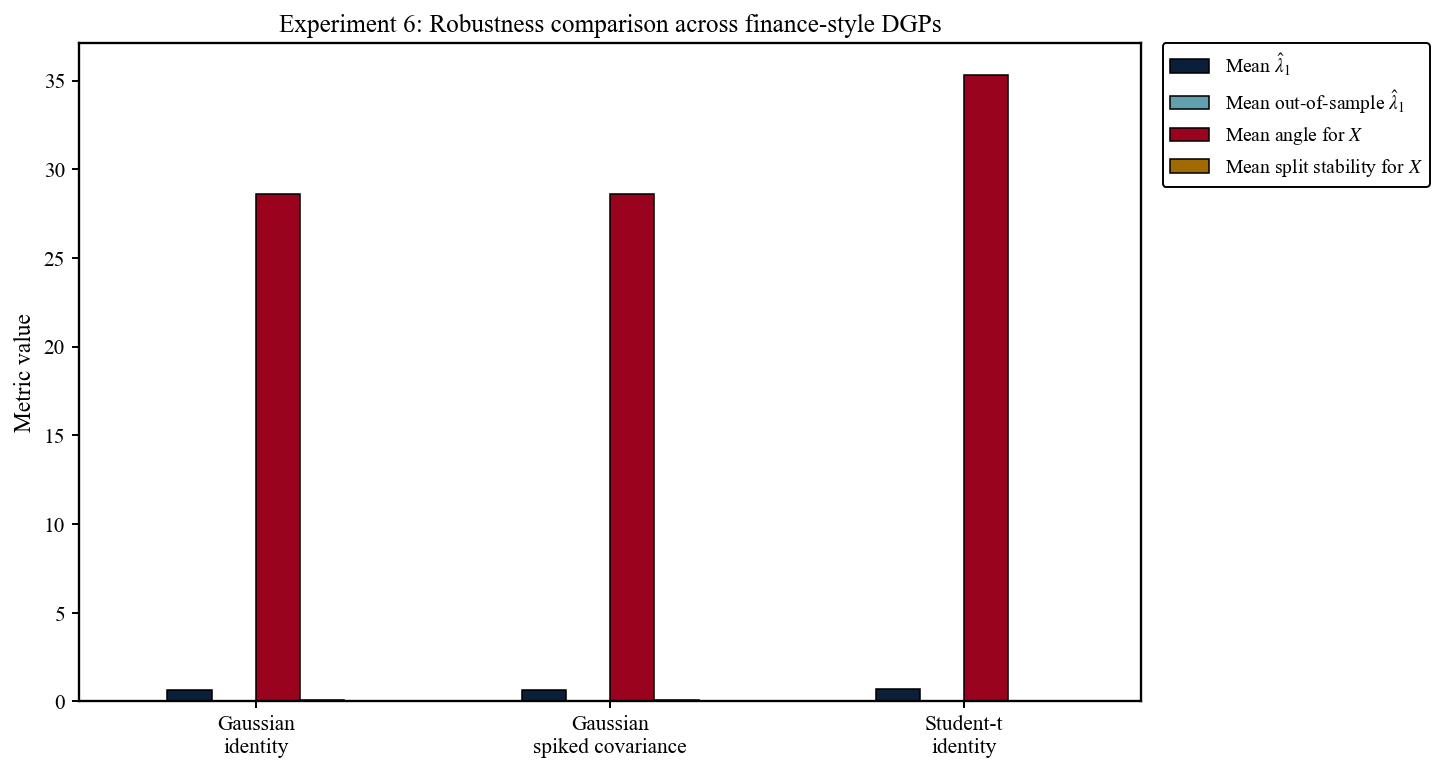

In [220]:
fig, ax = thesis_figure(figsize=(10.2, 5.4))
plot_df.rename(
    columns={
        "lambda1_hat_mean": r"Mean $\hat{\lambda}_1$",
        "lambda1_oos_mean": r"Mean out-of-sample $\hat{\lambda}_1$",
        "angle_x_deg_mean": r"Mean angle for $X$",
        "split_sqcos_x_mean": r"Mean split stability for $X$",
    }
).plot(
    kind="bar",
    ax=ax,
    color=[THESIS_COLORS["navy"], THESIS_COLORS["teal"], THESIS_COLORS["red"], THESIS_COLORS["gold"]],
    edgecolor="black",
    linewidth=0.8,
)
ax.set_ylabel("Metric value")
ax.set_title("Experiment 6: Robustness comparison across finance-style DGPs")
ax.set_xlabel("")
ax.set_xticklabels(["Gaussian\nidentity", "Gaussian\nspiked covariance", "Student-t\nidentity"], rotation=0)
style_axes(ax)
outside_legend(ax)
plt.show()

# export
export_figure(fig, "mc_exp6_robustness")
plt.close(fig)

In [221]:
metrics_to_plot_reduced = ["lambda1_hat_mean", "lambda1_oos_mean", "split_sqcos_x_mean"]
plot_df_reduced = exp6_summary.set_index("setting")[metrics_to_plot_reduced]

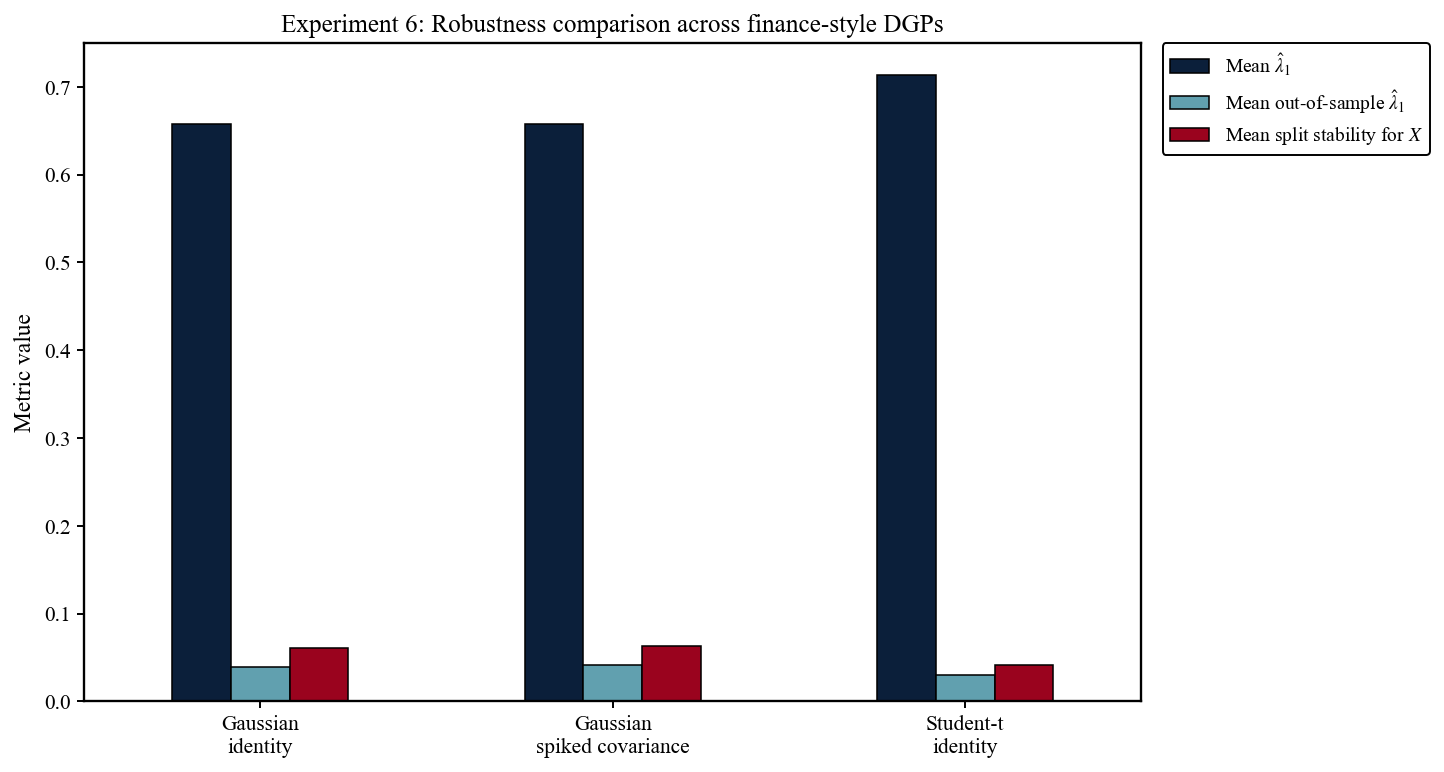

In [222]:
fig, ax = thesis_figure(figsize=(10.2, 5.4))
plot_df_reduced.rename(
    columns={
        "lambda1_hat_mean": r"Mean $\hat{\lambda}_1$",
        "lambda1_oos_mean": r"Mean out-of-sample $\hat{\lambda}_1$",
        "split_sqcos_x_mean": r"Mean split stability for $X$",
    }
).plot(
    kind="bar",
    ax=ax,
    color=[THESIS_COLORS["navy"], THESIS_COLORS["teal"], THESIS_COLORS["red"]],
    edgecolor="black",
    linewidth=0.8,
)
ax.set_ylabel("Metric value")
ax.set_title("Experiment 6: Robustness comparison across finance-style DGPs")
ax.set_xlabel("")
ax.set_xticklabels(["Gaussian\nidentity", "Gaussian\nspiked covariance", "Student-t\nidentity"], rotation=0)
style_axes(ax)
outside_legend(ax)
plt.show()

### **BG correction diagnostic**

The finance-style robustness check asks whether the correction formulas remain useful when the clean Gaussian benchmark is relaxed. Since the true signal is fixed at \(\rho=0.70\), the target is \(\rho^2=0.49\). The comparison below shows whether the BG correction moves the inflated sample root back toward this value and whether the angle formula remains close to the realized recovery error.


In [223]:
exp6_correction_summary = exp6_summary[[
    "setting",
    "rho2_mean",
    "lambda1_hat_mean",
    "bg_has_admissible_root_mean",
    "bg_rho2_hat_mean",
    "bg_bias_vs_rho2_mean",
    "angle_x_deg_mean",
    "bg_pred_angle_x_deg_mean",
    "lambda1_oos_mean",
    "split_sqcos_x_mean",
]].copy()
exp6_correction_summary["setting_label"] = exp6_correction_summary["setting"].map({
    "gaussian_identity": "Gaussian identity",
    "gaussian_spiked_cov": "Gaussian spiked covariance",
    "student_t_identity": "Student-t identity",
})
exp6_correction_summary

,setting,rho2_mean,lambda1_hat_mean,bg_has_admissible_root_mean,bg_rho2_hat_mean,bg_bias_vs_rho2_mean,angle_x_deg_mean,bg_pred_angle_x_deg_mean,lambda1_oos_mean,split_sqcos_x_mean,setting_label
0,gaussian_identity,0.49,0.658157,1.0,0.487303,-0.002697,28.589896,27.079109,0.039425,0.061368,Gaussian identity
1,gaussian_spiked_cov,0.49,0.657999,1.0,0.487067,-0.002933,28.611146,27.087770,0.041028,0.062799,Gaussian spiked covariance
2,student_t_identity,0.49,0.713796,1.0,0.575510,0.085510,35.335107,22.257514,0.029924,0.041034,Student-t identity


In [224]:
exp6_correction_table = exp6_correction_summary.drop(columns=["setting_label"]).copy()
exp6_correction_table["setting"] = exp6_correction_table["setting"].map({
    "gaussian_identity": "Gaussian identity",
    "gaussian_spiked_cov": "Gaussian spiked covariance",
    "student_t_identity": "Student-t identity",
})
exp6_correction_table = exp6_correction_table.rename(columns={
    "setting": "Setting",
    "rho2_mean": r"$\rho^2$",
    "lambda1_hat_mean": r"Mean $\hat{\lambda}_1$",
    "bg_has_admissible_root_mean": "Valid BG share",
    "bg_rho2_hat_mean": r"Mean BG $\widehat{\rho^2}$",
    "bg_bias_vs_rho2_mean": "Mean BG bias",
    "angle_x_deg_mean": r"Observed angle, $X$ (deg)",
    "bg_pred_angle_x_deg_mean": r"BG angle, $X$ (deg)",
    "lambda1_oos_mean": r"Mean out-of-sample $\hat{\lambda}_1$",
    "split_sqcos_x_mean": r"Mean split stability, $X$",
})
export_table(exp6_correction_table, "mc_exp6_bg_correction_summary")

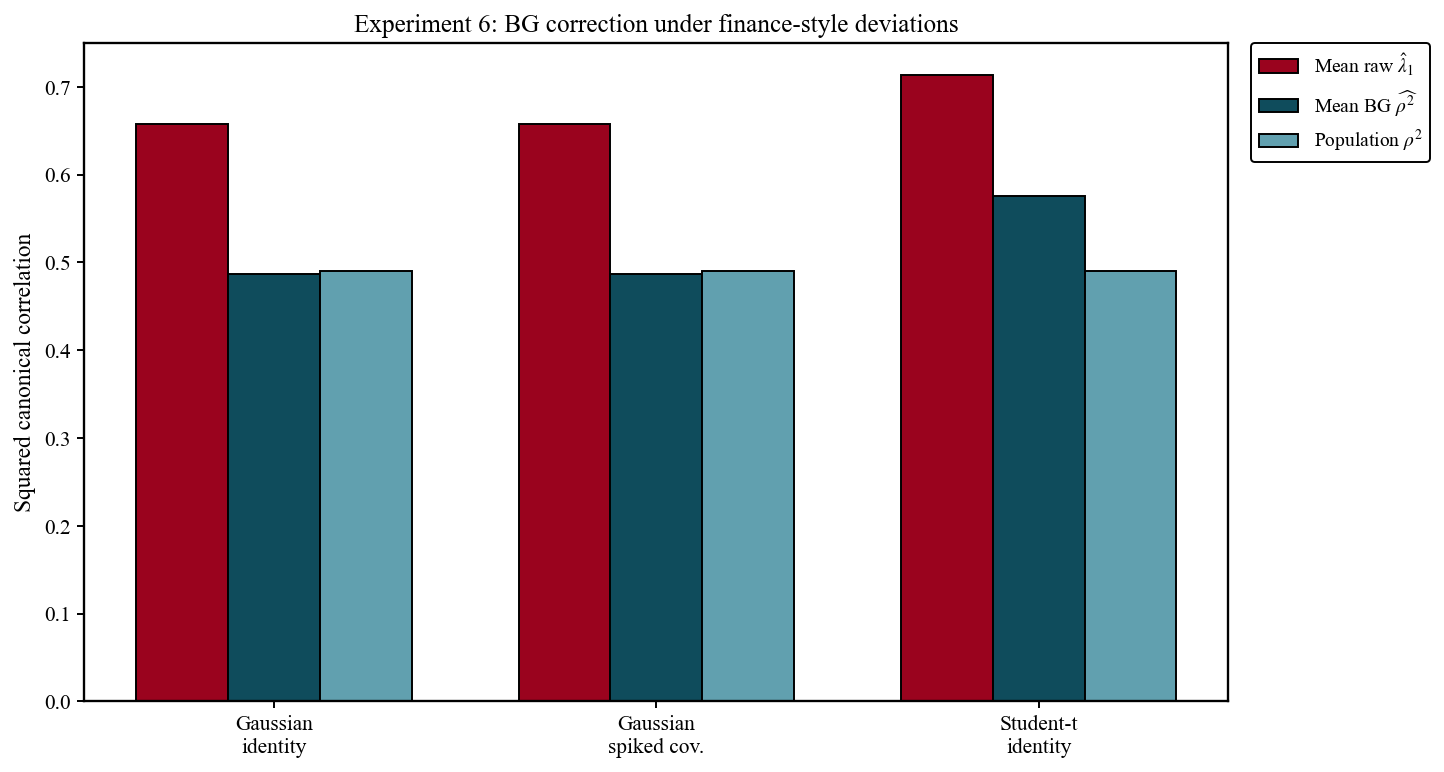

In [227]:
fig, ax = thesis_figure(figsize=(10.2, 5.4))
x = np.arange(len(exp6_correction_summary))
width = 0.24
ax.bar(x - width, exp6_correction_summary["lambda1_hat_mean"], width=width, color=THESIS_COLORS["red"], edgecolor="black", 
       label=r"Mean raw $\hat{\lambda}_1$")
ax.bar(x , exp6_correction_summary["bg_rho2_hat_mean"], width=width, color=THESIS_COLORS["darkteal"], edgecolor="black", 
       label=r"Mean BG $\widehat{\rho^2}$")
ax.bar(x + width, exp6_correction_summary["rho2_mean"], width=width, color=THESIS_COLORS["teal"], edgecolor="black", label=r"Population $\rho^2$")
ax.set_xticks(x)
ax.set_xticklabels(["Gaussian\nidentity", "Gaussian\nspiked cov.", "Student-t\nidentity"], rotation=0)
ax.set_ylabel("Squared canonical correlation")
ax.set_title("Experiment 6: BG correction under finance-style deviations")
style_axes(ax)
outside_legend(ax)
plt.show()

# export 
export_figure(fig, "mc_exp6_bg_root_correction")
plt.close(fig)

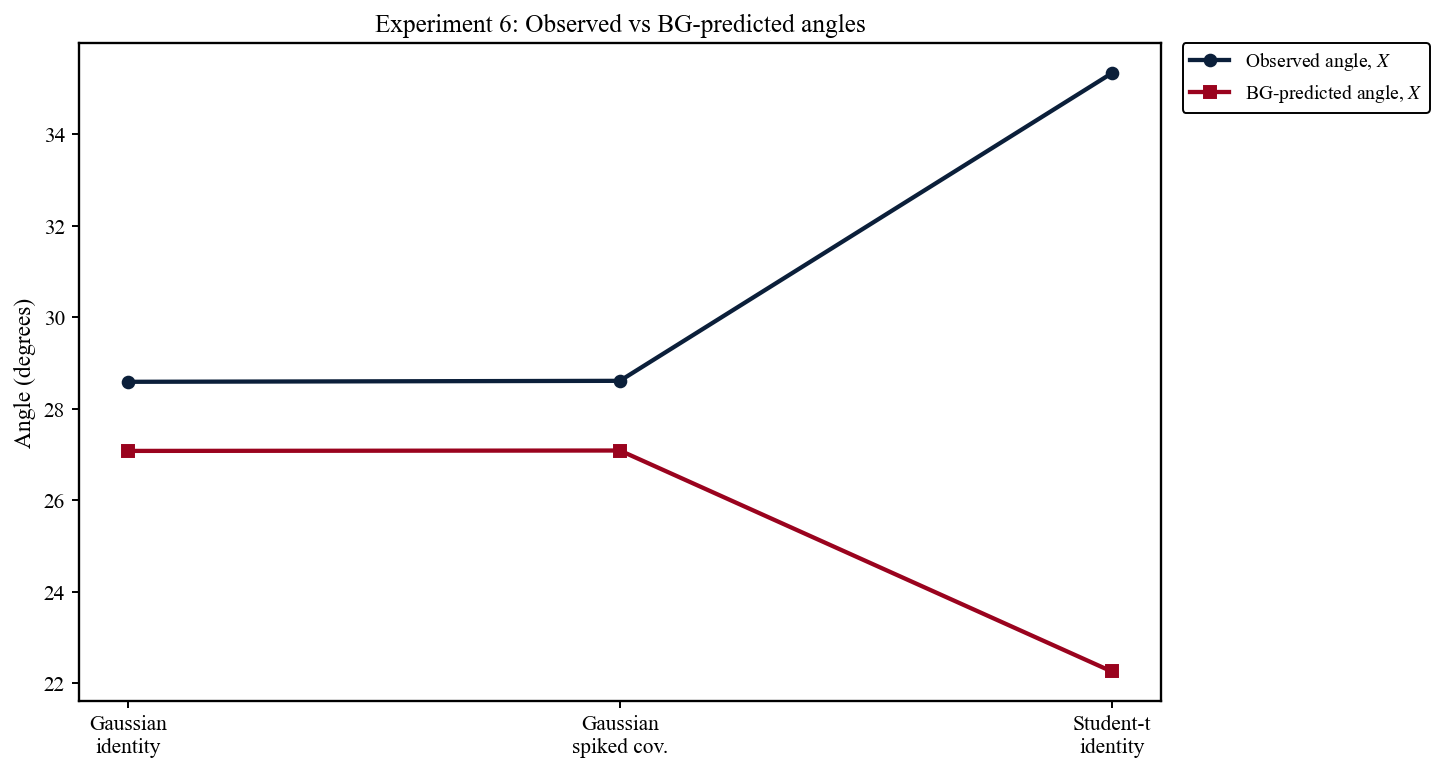

In [226]:
fig, ax = thesis_figure(figsize=(10.2, 5.4))
ax.plot(x, exp6_correction_summary["angle_x_deg_mean"], marker="o", linewidth=2.2, color=THESIS_COLORS["navy"], label=r"Observed angle, $X$")
ax.plot(x, exp6_correction_summary["bg_pred_angle_x_deg_mean"], marker="s", linewidth=2.2, color=THESIS_COLORS["red"], label=r"BG-predicted angle, $X$")
ax.set_xticks(x)
ax.set_xticklabels(["Gaussian\nidentity", "Gaussian\nspiked cov.", "Student-t\nidentity"], rotation=0)
ax.set_ylabel("Angle (degrees)")
ax.set_title("Experiment 6: Observed vs BG-predicted angles")
style_axes(ax)
outside_legend(ax)
plt.show()

#export 
export_figure(fig, "mc_exp6_bg_angles")
plt.close(fig)

The desired pattern is that the correction works best in the Gaussian identity benchmark, remains close under moderate within-panel covariance heterogeneity, and becomes less reliable under heavy tails. This directly informs the CRSP application: financial returns may produce large roots, but heavy tails can make spectral strength look cleaner than the recoverable canonical direction really is.


### **RESULTS**

Experiment 6 examines whether the main qualitative conclusions survive under more realistic data-generating mechanisms. Across all three settings, the leading root is always detected, with empirical detection probability equal to 1. This indicates that a population signal of size $\rho=0.70$ is strong enough to remain visible even when the benchmark assumptions are relaxed. Under the Gaussian identity design, the mean leading sample root is 0.6578; under Gaussian spiked within-panel covariance it is 0.6577; and under Student-$t$ innovations it rises to 0.7135. Thus, heavy tails generate noticeably stronger in-sample inflation, whereas moderate within-panel covariance heterogeneity leaves the leading root almost unchanged relative to the benchmark.

The recovery and stability measures are more informative than detection alone. In the Gaussian identity and Gaussian spiked-covariance cases, the mean out-of-sample leading root is about 0.04, the mean angle is about $28.5^\circ$, and the mean squared cosine overlap is about 0.77 on both sides. These two settings therefore deliver very similar qualitative conclusions: the spike is detectable and the associated vectors are recovered reasonably well. Under Student-$t$ innovations, however, recovery is visibly weaker. The mean out-of-sample leading root falls to 0.0314, the mean angle increases to about $35.2^\circ$, and the mean squared cosine overlap declines to about 0.667. The split-sample overlaps also fall from roughly 0.06 in the Gaussian settings to about 0.04 under heavy tails. Therefore, the main HDCCA conclusions are robust to mild covariance misspecification, but heavy tails make the signal look stronger in sample than it is out of sample and reduce the reliability of vector recovery.


The correction columns make this robustness point sharper. Under Gaussian identity and Gaussian spiked-covariance designs, the BG-corrected root should remain close to the true \(
ho^2=0.49\), while the raw sample root is inflated. Under Student-\(t\) innovations, the raw root is more inflated and the angle recovery worsens, so the correction should be interpreted more cautiously. This is exactly the empirical concern in financial data: heavy tails can make spectral dependence look stronger than the recoverable canonical direction actually is.


### Main Results Table

This cell constructs a compact, research-paper style table from the exported Monte Carlo summaries. Each row reports the relevant design, population signal, spectral evidence, validation evidence, and the inference used in the thesis. The table is exported as `mc_main_results_summary.csv` and `mc_main_results_summary.tex`.


In [237]:
# Compact thesis table: main Monte Carlo simulation results
from pathlib import Path
import pandas as pd

if "EXPORT_DIR" not in globals():
    candidates = [
        Path.cwd() / "Editor Econ" / "imagenes",
        Path.cwd().parent / "Editor Econ" / "imagenes",
    ]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            EXPORT_DIR = candidate
            break
    else:
        EXPORT_DIR = Path.cwd() / "imagenes"
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)

mc_dir = Path(EXPORT_DIR)

def read_mc_csv(stem):
    return pd.read_csv(mc_dir / f"{stem}.csv")

def metric(df, label):
    return float(df.loc[df["Metric"].eq(label), "Value"].iloc[0])

def fmt(x, digits=3):
    return f"{x:.{digits}f}"

def fmt1(x):
    return f"{x:.1f}"

exp1 = read_mc_csv("mc_exp1_summary")
exp2 = read_mc_csv("mc_exp2_summary")
exp3 = read_mc_csv("mc_exp3_summary")
exp4 = read_mc_csv("mc_exp4_summary")
exp4_comp = read_mc_csv("mc_exp4_components")
exp5 = read_mc_csv("mc_exp5_summary")
exp6 = read_mc_csv("mc_exp6_summary")

exp2_strong = exp2.iloc[(exp2[r"$\rho$"] - 0.690909).abs().argsort()].iloc[0]
exp3_threshold = exp3.iloc[(exp3[r"$\rho$"] - 0.4264014327112209).abs().argsort()].iloc[0]
exp3_upper = exp3.iloc[-1]
exp5_low = exp5.loc[exp5["Design"].eq("Low-rank")].iloc[0]
exp5_diffuse = exp5.loc[exp5["Design"].eq("Diffuse")].iloc[0]
exp6_gauss = exp6.loc[exp6["Setting"].eq("Gaussian identity")].iloc[0]
exp6_spiked = exp6.loc[exp6["Setting"].eq("Gaussian spiked covariance")].iloc[0]
exp6_t = exp6.loc[exp6["Setting"].eq("Student-t identity")].iloc[0]

exp4_outliers = metric(exp4, "Mean number of outliers")
exp4_lambdas = "/".join(fmt(v) for v in exp4_comp[r"Mean $\hat{\lambda}_j$"].tolist())
exp4_cos2 = "/".join(fmt(v) for v in exp4_comp[r"Mean squared cosine, $X$"].tolist())
exp4_valid = "/".join(fmt(v) for v in exp4_comp["Valid BG share"].tolist())

compact_mc_results = pd.DataFrame([
    {
        "Finding": "Null inflation",
        "Experiment/design": "Exp. 1: independent panels",
        "Population signal": r"None ($\rho_j=0$)",
        "Spectral evidence": (
            r"mean $\hat{\lambda}_1=" + fmt(metric(exp1, r"Mean $\hat{\lambda}_1$"))
            + r"$; 99\% cutoff=" + fmt(metric(exp1, r"99\% null cutoff for $\hat{\lambda}_1$"))
        ),
        "Validation evidence": (
            r"OOS=" + fmt(metric(exp1, r"Mean out-of-sample $\hat{\lambda}_1$"))
            + r"; split $X$=" + fmt(metric(exp1, r"Mean split stability, $X$"))
        ),
        "Inference": "Large roots arise mechanically under high dimensionality.",
    },
    {
        "Finding": "Finite-sample threshold",
        "Experiment/design": "Exp. 3: threshold zoom",
        "Population signal": (
            r"$\rho_c\approx" + fmt(exp3_threshold[r"$\rho$"], 3)
            + r"$; upper grid $\rho=" + fmt(exp3_upper[r"$\rho$"], 3) + r"$"
        ),
        "Spectral evidence": (
            "detection=" + fmt(exp3_threshold["Detection probability"])
            + " at threshold; " + fmt(exp3_upper["Detection probability"])
            + r" at $\rho=" + fmt(exp3_upper[r"$\rho$"], 3) + r"$"
        ),
        "Validation evidence": (
            r"OOS=" + fmt(exp3_threshold[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + r" to " + fmt(exp3_upper[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + r"; angle $X$=" + fmt1(exp3_threshold[r"Mean angle, $X$ (deg)"])
            + r" to " + fmt1(exp3_upper[r"Mean angle, $X$ (deg)"]) + r"$^\circ$"
        ),
        "Inference": "Detectability rises gradually; vector recovery lags.",
    },
    {
        "Finding": "In-sample overstatement",
        "Experiment/design": "Exp. 2: one-spike sweep",
        "Population signal": (
            r"$\rho=" + fmt(exp2_strong[r"$\rho$"], 3)
            + r"$; $\rho^2=" + fmt(exp2_strong[r"$\rho^2$"]) + r"$"
        ),
        "Spectral evidence": (
            r"mean $\hat{\lambda}_1=" + fmt(exp2_strong[r"Mean $\hat{\lambda}_1$"])
            + r"$; raw bias="
            + fmt(exp2_strong[r"Mean $\hat{\lambda}_1$"] - exp2_strong[r"$\rho^2$"])
        ),
        "Validation evidence": (
            r"OOS=" + fmt(exp2_strong[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + r"; split $X$=" + fmt(exp2_strong[r"Mean split stability, $X$"])
            + r"; angle $X$=" + fmt1(exp2_strong[r"Mean angle, $X$ (deg)"]) + r"$^\circ$"
        ),
        "Inference": "A large in-sample root can still generalize weakly.",
    },
    {
        "Finding": "Component recovery",
        "Experiment/design": "Exp. 4: three-spike low rank",
        "Population signal": r"$\rho=(0.80,0.55,0.30)$",
        "Spectral evidence": "mean outliers=" + fmt(exp4_outliers) + r"; roots=" + exp4_lambdas,
        "Validation evidence": r"cos$^2_X$=" + exp4_cos2 + "; valid BG=" + exp4_valid,
        "Inference": "Only sufficiently strong components are stably recovered.",
    },
    {
        "Finding": "Low-rank vs diffuse",
        "Experiment/design": "Exp. 5: concentrated versus diffuse",
        "Population signal": (
            "rank 3, energy=" + fmt(exp5_low[r"Signal energy, $\sum \rho_j^2$"])
            + "; rank 10, energy=" + fmt(exp5_diffuse[r"Signal energy, $\sum \rho_j^2$"])
        ),
        "Spectral evidence": (
            "outliers=" + fmt(exp5_low["Mean number of outliers"])
            + "/" + fmt(exp5_diffuse["Mean number of outliers"])
            + r"; $\hat{\lambda}_1$=" + fmt(exp5_low[r"Mean $\hat{\lambda}_1$"])
            + "/" + fmt(exp5_diffuse[r"Mean $\hat{\lambda}_1$"])
        ),
        "Validation evidence": (
            "OOS=" + fmt(exp5_low[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + "/" + fmt(exp5_diffuse[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + "; split $X$=" + fmt(exp5_low[r"Mean split stability, $X$"])
            + "/" + fmt(exp5_diffuse[r"Mean split stability, $X$"])
        ),
        "Inference": "Diffuse dependence weakens separability and interpretation.",
    },
    {
        "Finding": "Finance-style robustness",
        "Experiment/design": "Exp. 6: Gaussian / spiked cov. / Student-$t$",
        "Population signal": r"one spike, $\rho^2=0.49$",
        "Spectral evidence": (
            "detection=1.000 all; roots="
            + fmt(exp6_gauss[r"Mean $\hat{\lambda}_1$"])
            + "/" + fmt(exp6_spiked[r"Mean $\hat{\lambda}_1$"])
            + "/" + fmt(exp6_t[r"Mean $\hat{\lambda}_1$"])
        ),
        "Validation evidence": (
            "OOS=" + fmt(exp6_gauss[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + "/" + fmt(exp6_spiked[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + "/" + fmt(exp6_t[r"Mean out-of-sample $\hat{\lambda}_1$"])
            + "; split $X$=" + fmt(exp6_gauss[r"Mean split stability, $X$"])
            + "/" + fmt(exp6_spiked[r"Mean split stability, $X$"])
            + "/" + fmt(exp6_t[r"Mean split stability, $X$"])
        ),
        "Inference": "Heavy tails amplify roots and reduce recovery quality.",
    },
])

compact_mc_results.to_csv(mc_dir / "mc_main_results_summary.csv", index=False)
compact_mc_results.to_latex(
    mc_dir / "mc_main_results_summary.tex",
    index=False,
    escape=False,
    column_format=(
        r"p{0.115\linewidth}"
        r"p{0.155\linewidth}"
        r"p{0.145\linewidth}"
        r"p{0.205\linewidth}"
        r"p{0.205\linewidth}"
        r"p{0.175\linewidth}"
    ),
)

print(f"Exported compact table to: {mc_dir / 'mc_main_results_summary.tex'}")
compact_mc_results


Exported compact table to: /Users/albatorres/Desktop/UC3M/TFG Econ./Editor Econ/imagenes/mc_main_results_summary.tex


,Finding,Experiment/design,Population signal,Spectral evidence,Validation evidence,Inference
0,Null inflation,Exp. 1: independent panels,None ($\rho_j=0$),mean $\hat{\lambda}_1=0.505$; 99\% cutoff=0.545,OOS=0.004; split $X$=0.012,Large roots arise mechanically under high dime...
1,Finite-sample threshold,Exp. 3: threshold zoom,$\rho_c\approx0.426$; upper grid $\rho=0.546$,detection=0.061 at threshold; 0.598 at $\rho=0...,OOS=0.004 to 0.006; angle $X$=68.9 to 47.2$^\c...,Detectability rises gradually; vector recovery...
2,In-sample overstatement,Exp. 2: one-spike sweep,$\rho=0.691$; $\rho^2=0.477$,mean $\hat{\lambda}_1=0.651$; raw bias=0.174,OOS=0.035; split $X$=0.053; angle $X$=29.3$^\c...,A large in-sample root can still generalize we...
3,Component recovery,Exp. 4: three-spike low rank,"$\rho=(0.80,0.55,0.30)$",mean outliers=1.589; roots=0.755/0.552/0.494,cos$^2_X$=0.872/0.466/0.041; valid BG=1.000/0....,Only sufficiently strong components are stably...
4,Low-rank vs diffuse,Exp. 5: concentrated versus diffuse,"rank 3, energy=1.243; rank 10, energy=0.762",outliers=2.108/0.130; $\hat{\lambda}_1$=0.735/...,OOS=0.140/0.005; split $X$=0.190/0.013,Diffuse dependence weakens separability and in...
5,Finance-style robustness,Exp. 6: Gaussian / spiked cov. / Student-$t$,"one spike, $\rho^2=0.49$",detection=1.000 all; roots=0.658/0.658/0.714,OOS=0.039/0.041/0.030; split $X$=0.061/0.063/0...,Heavy tails amplify roots and reduce recovery ...


In [ ]:
# check output directory
# print(f"Exported Monte Carlo figures and tables to: {EXPORT_DIR}")

Exported Monte Carlo figures and tables to: /Users/albatorres/Desktop/UC3M/TFG Econ./Editor Econ/imagenes
